<a href="https://colab.research.google.com/github/emimkuri/NBA_MultiFacet_Clustering/blob/main/Tesis_NBA_data_API.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **IMPORTING PLAYER BIO DATA**

In [1]:
!pip install nba_api matplotlib seaborn scikit-learn --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.0/319.0 kB 3.4 MB/s eta 0:00:00


In [2]:
from nba_api.stats.endpoints import leaguedashplayerstats, leaguedashptstats, leaguehustlestatsplayer, leaguedashplayerbiostats, shotchartdetail, leaguedashptdefend
from nba_api.stats.static import players
import matplotlib.pyplot as plt
import pandas as pd
#from matplotlib.patches import Circle, Rectangle, Arc
import time
import numpy as np
#import plotly.graph_objects as go
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.manifold import TSNE
from scipy.stats import skew
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

df = leaguedashplayerstats.LeagueDashPlayerStats(season='2024-25',season_type_all_star='Regular Season',per_mode_detailed='Totals').get_data_frames()[0]

In [3]:
bio = leaguedashplayerbiostats.LeagueDashPlayerBioStats(season='2024-25', per_mode_simple='Totals').get_data_frames()[0]
bio = bio.drop(['PLAYER_NAME','TEAM_ID','TEAM_ABBREVIATION','AGE', 'NET_RATING', 'AST', 'REB', 'PTS', 'GP', 'PLAYER_HEIGHT_INCHES'], axis = 1)

In [4]:
position = leaguedashptdefend.LeagueDashPtDefend(season="2024-25", per_mode_simple='Totals').get_data_frames()[0]
position = position[['CLOSE_DEF_PERSON_ID', 'PLAYER_POSITION']]
position = position.rename(columns= {'CLOSE_DEF_PERSON_ID': 'PLAYER_ID'})

In [5]:
# FINAL GENERAL INFO DATA
general = pd.merge(df, bio, how='inner', on='PLAYER_ID')
general = general.drop(['W','L','W_PCT','PLUS_MINUS', 'NBA_FANTASY_PTS', 'DD2', 'TD3', 'WNBA_FANTASY_PTS', 'GP_RANK', 'W_RANK', 'L_RANK', 'W_PCT_RANK', 'MIN_RANK', 'FGM_RANK', 'FGA_RANK', 'FG_PCT_RANK', 'FG3M_RANK', 'FG3A_RANK', 'FG3_PCT_RANK', 'FTM_RANK', 'FTA_RANK', 'FT_PCT_RANK', 'OREB_RANK', 'DREB_RANK', 'REB_RANK', 'AST_RANK', 'TOV_RANK', 'STL_RANK', 'BLK_RANK', 'BLKA_RANK', 'PF_RANK', 'PFD_RANK', 'PTS_RANK', 'PLUS_MINUS_RANK', 'NBA_FANTASY_PTS_RANK', 'DD2_RANK', 'TD3_RANK', 'WNBA_FANTASY_PTS_RANK', 'TEAM_COUNT'], axis=1)
general = pd.merge(general, position, how='inner', on='PLAYER_ID')

# **IMPORTING DATA**
- GENERAL
- SHOOTING
- PLAYMAKING
- DEFENSE
- REBOUNDS

In [30]:
catch_shoot = leaguedashptstats.LeagueDashPtStats(season='2024-25',season_type_all_star='Regular Season',player_or_team='Player',pt_measure_type='CatchShoot',per_mode_simple='Totals').get_data_frames()[0]
nba_teams = df['TEAM_ID'].unique()
catch_shoot = catch_shoot[catch_shoot['TEAM_ID'].isin(nba_teams)]
defense = leaguedashptstats.LeagueDashPtStats(season='2024-25',season_type_all_star='Regular Season',player_or_team='Player',pt_measure_type='Defense',per_mode_simple='Totals').get_data_frames()[0]
rebound = leaguedashptstats.LeagueDashPtStats(season='2024-25',season_type_all_star='Regular Season',player_or_team='Player',pt_measure_type='Rebounding',per_mode_simple='Totals').get_data_frames()[0]
drives = leaguedashptstats.LeagueDashPtStats(season='2024-25',season_type_all_star='Regular Season',player_or_team='Player',pt_measure_type='Drives',per_mode_simple='Totals').get_data_frames()[0]
passing = leaguedashptstats.LeagueDashPtStats(season='2024-25',season_type_all_star='Regular Season',player_or_team='Player',pt_measure_type='Passing',per_mode_simple='Totals').get_data_frames()[0]
efficiency = leaguedashptstats.LeagueDashPtStats(season='2024-25',season_type_all_star='Regular Season',player_or_team='Player',pt_measure_type='Efficiency',per_mode_simple='Totals').get_data_frames()[0]
speed_distance = leaguedashptstats.LeagueDashPtStats(season='2024-25',season_type_all_star='Regular Season',player_or_team='Player',pt_measure_type='SpeedDistance',per_mode_simple='Totals').get_data_frames()[0]

play_stats = leaguehustlestatsplayer.LeagueHustleStatsPlayer(season="2024-25", per_mode_time = "Totals").get_data_frames()[0]
reb_stats = leaguehustlestatsplayer.LeagueHustleStatsPlayer(season="2024-25", per_mode_time = "Totals").get_data_frames()[0]
def_3shoots = leaguedashptdefend.LeagueDashPtDefend(season="2024-25", defense_category= '3 Pointers', per_mode_simple='Totals').get_data_frames()[0]
def_shoots = leaguedashptdefend.LeagueDashPtDefend(season="2024-25", per_mode_simple='Totals').get_data_frames()[0]
def_stats = leaguehustlestatsplayer.LeagueHustleStatsPlayer(season="2024-25", per_mode_time = "Totals").get_data_frames()[0]

In [31]:
# Final Shooting dataset CURRENTLY IN TOTALS
df_shoot = df[['PLAYER_ID','FGM','FGA','FG_PCT','FG3M','FG3A','FG3_PCT','FTM','FTA','FT_PCT','PTS']]
shoot = pd.merge(catch_shoot, df_shoot, how='inner', on='PLAYER_ID')
drive_shoot = drives[['PLAYER_ID', 'DRIVE_FGM', 'DRIVE_FGA', 'DRIVE_FG_PCT', 'DRIVE_FTM', 'DRIVE_FTA', 'DRIVE_FT_PCT', 'DRIVE_PTS', 'DRIVE_PTS_PCT']]
shoot = pd.merge(shoot, drive_shoot, how='inner', on='PLAYER_ID')
efficiency_shoot = efficiency[['PLAYER_ID', 'PULL_UP_PTS', 'PULL_UP_FG_PCT', 'PAINT_TOUCH_PTS', 'PAINT_TOUCH_FG_PCT', 'POST_TOUCH_PTS', 'POST_TOUCH_FG_PCT', 'ELBOW_TOUCH_PTS','ELBOW_TOUCH_FG_PCT','EFF_FG_PCT']]
shoot = pd.merge(shoot, efficiency_shoot, how='inner', on='PLAYER_ID')
shoot = pd.merge(shoot, position, how='inner', on='PLAYER_ID')
shoot = pd.merge(shoot, general[['PLAYER_ID','USG_PCT','TS_PCT']], how='inner', on='PLAYER_ID')

In [32]:
# FINAL REB DF IN TOTALS
reb_stats = reb_stats[['PLAYER_ID', 'BOX_OUTS', 'BOX_OUT_PLAYER_TEAM_REBS','BOX_OUT_PLAYER_REBS', 'PCT_BOX_OUTS_OFF', 'PCT_BOX_OUTS_DEF']]
rebound = pd.merge(rebound, reb_stats, how='inner', on='PLAYER_ID')
rebound = pd.merge(rebound, position, how='inner', on='PLAYER_ID')
rebound = pd.merge(rebound, general[['PLAYER_ID','DREB_PCT', 'OREB_PCT']])

In [33]:
# FINAL PLAYMAKING DATAFrame IN TOTALS
play_stats = play_stats[['PLAYER_ID', 'SCREEN_ASSISTS','SCREEN_AST_PTS']]
passing = pd.merge(passing, play_stats, how='inner', on='PLAYER_ID')
df_play = df[['PLAYER_ID', 'TOV']]
passing = pd.merge(passing, df_play, how='inner', on = 'PLAYER_ID')
drive_play = drives[['PLAYER_ID','DRIVE_PASSES','DRIVE_PASSES_PCT','DRIVE_AST','DRIVE_AST_PCT', 'DRIVE_TOV','DRIVE_TOV_PCT']]
passing = pd.merge(passing, drive_play, how='inner', on = 'PLAYER_ID')
passing = pd.merge(passing, position, how='inner', on='PLAYER_ID')
passing = pd.merge(passing, general[['PLAYER_ID','AST_PCT']])

In [34]:
# FINAL DEF DF IN TOTALS
def_3shoots = def_3shoots.rename(columns= {'CLOSE_DEF_PERSON_ID': 'PLAYER_ID', 'PLUSMINUS': '3_PLUSMINUS'})
def_3shoots = def_3shoots[['PLAYER_ID', '3_PLUSMINUS']]
def_shoots = def_shoots[['CLOSE_DEF_PERSON_ID', 'D_FGM','D_FGA','D_FG_PCT','NORMAL_FG_PCT','PCT_PLUSMINUS']]
def_shoots = def_shoots.rename(columns= {'CLOSE_DEF_PERSON_ID': 'PLAYER_ID'})
def_stats = def_stats[['PLAYER_ID', 'DEFLECTIONS', 'LOOSE_BALLS_RECOVERED']]
defense = pd.merge(defense, def_stats, how='inner', on='PLAYER_ID')
df_defensive = df[['PLAYER_ID', 'PF']]
defense = pd.merge(defense, df_defensive, how='inner', on='PLAYER_ID')
defense = pd.merge(defense, def_shoots, how='inner', on='PLAYER_ID')
defense = pd.merge(defense, position, how='inner', on='PLAYER_ID')
running_def = speed_distance[['PLAYER_ID', 'DIST_MILES_DEF', 'AVG_SPEED']]
defense = pd.merge(defense, running_def, how='inner', on='PLAYER_ID')
defense = pd.merge(defense, def_3shoots, how='inner', on='PLAYER_ID')
defense = pd.merge(defense, play_stats, how='inner', on='PLAYER_ID')
defense = pd.merge(defense, df_play, how='inner', on='PLAYER_ID')
ast_df = general[['PLAYER_ID', 'AST','BLKA','PFD']]
defense = pd.merge(defense, ast_df, how='inner', on='PLAYER_ID')

In [35]:
# data consistency issue for the MIN and GP played variable in the rebound dataframe.
#Solution will be to normalize all using the main, general dataframe which after consideration, was the true minutes played variable
standard_stats = general[['PLAYER_ID', 'MIN', 'GP']]
shoot = (shoot.drop(columns=['MIN', 'GP', 'W', 'L'], errors='ignore').merge(standard_stats, on='PLAYER_ID', how='left'))
rebound = (rebound.drop(columns=['MIN', 'GP', 'W', 'L'], errors='ignore').merge(standard_stats, on='PLAYER_ID', how='left'))
passing = (passing.drop(columns=['MIN', 'GP', 'W','L'], errors='ignore').merge(standard_stats, on='PLAYER_ID', how='left'))
defense = (defense.drop(columns=['MIN', 'GP','W','L'], errors='ignore').merge(standard_stats, on='PLAYER_ID', how='left'))


In [36]:
print(general.shape)
print(shoot.shape)
print(defense.shape)
print(rebound.shape)
print(passing.shape)

(568, 51)
(568, 44)
(564, 30)
(562, 41)
(566, 27)


# **Data Quality**

In [37]:
pd.set_option('display.max_rows', None)
print(general.isnull().sum())
print(shoot.isnull().sum())
print(defense.isnull().sum())
print(rebound.isnull().sum())
print(passing.isnull().sum())
# No NULL Values except from some percentage variables

PLAYER_ID            0
PLAYER_NAME          0
NICKNAME             0
TEAM_ID              0
TEAM_ABBREVIATION    0
AGE                  0
GP                   0
MIN                  0
FGM                  0
FGA                  0
FG_PCT               0
FG3M                 0
FG3A                 0
FG3_PCT              0
FTM                  0
FTA                  0
FT_PCT               0
OREB                 0
DREB                 0
REB                  0
AST                  0
TOV                  0
STL                  0
BLK                  0
BLKA                 0
PF                   0
PFD                  0
PTS                  0
PLAYER_HEIGHT        0
PLAYER_WEIGHT        2
COLLEGE              0
COUNTRY              0
DRAFT_YEAR           0
DRAFT_ROUND          1
DRAFT_NUMBER         2
OREB_PCT             0
DREB_PCT             0
USG_PCT              0
TS_PCT               0
AST_PCT              0
PLAYER_POSITION      0
cluster              0
cluster_prob_0       0
cluster_pro

In [38]:
shoot['CATCH_SHOOT_FG3M'].fillna(0, inplace=True)
shoot['CATCH_SHOOT_FG3A'].fillna(0, inplace=True)
shoot['CATCH_SHOOT_FG3_PCT'].fillna(0, inplace=True)
shoot['CATCH_SHOOT_EFG_PCT'].fillna(0, inplace=True)

In [39]:
for i, row in general.iterrows():
    if row['MIN'] > 3936:
        print(f"{i}: Inconsistent minutes ({row['MIN']})")
    elif row['FGM'] > row['FGA'] or row['FG3M'] > row['FG3A'] or row['FTM'] > row['FTA']:
        print(f"{i}: Inconsistent makes/attempts")
    elif not (0 <= row['FG_PCT'] <= 1) or not (0 <= row['FG3_PCT'] <= 1) or not (0 <= row['FT_PCT'] <= 1):
        print(f"{i}: Percentage out of bounds")
    else:
        print(f"{i}: good")



0: good
1: good
2: good
3: good
4: good
5: good
6: good
7: good
8: good
9: good
10: good
11: good
12: good
13: good
14: good
15: good
16: good
17: good
18: good
19: good
20: good
21: good
22: good
23: good
24: good
25: good
26: good
27: good
28: good
29: good
30: good
31: good
32: good
33: good
34: good
35: good
36: good
37: good
38: good
39: good
40: good
41: good
42: good
43: good
44: good
45: good
46: good
47: good
48: good
49: good
50: good
51: good
52: good
53: good
54: good
55: good
56: good
57: good
58: good
59: good
60: good
61: good
62: good
63: good
64: good
65: good
66: good
67: good
68: good
69: good
70: good
71: good
72: good
73: good
74: good
75: good
76: good
77: good
78: good
79: good
80: good
81: good
82: good
83: good
84: good
85: good
86: good
87: good
88: good
89: good
90: good
91: good
92: good
93: good
94: good
95: good
96: good
97: good
98: good
99: good
100: good
101: good
102: good
103: good
104: good
105: good
106: good
107: good
108: good
109: good
110: good


# **EDA**

EDA complete

In [40]:
total_mins = general['MIN'].describe()
cutoff = total_mins['25%']
print(f"25% of Total_Mins: {cutoff}")

25% of Total_Mins: 314.57666666666665


EDA filtered

In [41]:
general = general[general['MIN'] > cutoff]

In [42]:
shoot = shoot[shoot['MIN'] > cutoff]

In [43]:
defense = defense[defense['MIN'] > cutoff]

In [44]:
rebound = rebound[rebound['MIN'] > cutoff]

In [45]:
passing = passing[passing['MIN'] > cutoff]

In [46]:
print(len(general))
print(len(shoot))
print(len(defense))
print(len(rebound))
print(len(passing))

426
426
426
426
426


In [47]:
pd.set_option('display.max_rows', None)
print(general.isnull().sum())
print(shoot.isnull().sum())
print(defense.isnull().sum())
print(rebound.isnull().sum())
print(passing.isnull().sum())

PLAYER_ID            0
PLAYER_NAME          0
NICKNAME             0
TEAM_ID              0
TEAM_ABBREVIATION    0
AGE                  0
GP                   0
MIN                  0
FGM                  0
FGA                  0
FG_PCT               0
FG3M                 0
FG3A                 0
FG3_PCT              0
FTM                  0
FTA                  0
FT_PCT               0
OREB                 0
DREB                 0
REB                  0
AST                  0
TOV                  0
STL                  0
BLK                  0
BLKA                 0
PF                   0
PFD                  0
PTS                  0
PLAYER_HEIGHT        0
PLAYER_WEIGHT        1
COLLEGE              0
COUNTRY              0
DRAFT_YEAR           0
DRAFT_ROUND          1
DRAFT_NUMBER         2
OREB_PCT             0
DREB_PCT             0
USG_PCT              0
TS_PCT               0
AST_PCT              0
PLAYER_POSITION      0
cluster              0
cluster_prob_0       0
cluster_pro

# **PER 36 CONVERSION**

In [48]:
# function to convert needed stats into per36 stats
def per36_conversion(df, stats):
  for stat in stats:
    df[stat] = round(df[stat]/ df['MIN']*36, 2)
  return df

general_stats_to_convert = ['FGM','FGA', 'FG3M','FG3A','FTM','FTA','OREB','DREB','REB','AST', 'TOV','STL', 'BLK', 'BLKA','PF','PFD','PTS']

pass_stats_to_convert = ['PASSES_MADE','PASSES_RECEIVED','AST','FT_AST','SECONDARY_AST','POTENTIAL_AST','AST_PTS_CREATED','AST_ADJ',
                         'SCREEN_ASSISTS','SCREEN_AST_PTS','TOV','DRIVE_PASSES', 'DRIVE_AST','DRIVE_TOV']

shoot_stats_to_convert = ['CATCH_SHOOT_FGM','CATCH_SHOOT_FGA', 'CATCH_SHOOT_PTS','CATCH_SHOOT_FG3M','CATCH_SHOOT_FG3A', 'FGM', 'FGA', 'FG3M','FG3A', 'FTM',
                          'FTA','PTS','DRIVE_FGM','DRIVE_FGA', 'DRIVE_FTM','DRIVE_FTA', 'DRIVE_PTS', 'PULL_UP_PTS', 'PAINT_TOUCH_PTS','POST_TOUCH_PTS','ELBOW_TOUCH_PTS']

defense_stats_to_convert = ['STL','BLK','DREB','DEF_RIM_FGM','DEF_RIM_FGA','DEFLECTIONS','LOOSE_BALLS_RECOVERED','PF','D_FGM','D_FGA',
                            'DIST_MILES_DEF','SCREEN_ASSISTS','SCREEN_AST_PTS','TOV','AST','BLKA','PFD']

rebound_stats_to_convert = ['OREB','OREB_CONTEST','OREB_UNCONTEST','OREB_CHANCES','OREB_CHANCE_DEFER','DREB',
                            'DREB_CONTEST','DREB_UNCONTEST','DREB_CHANCES','DREB_CHANCE_DEFER','REB','REB_CONTEST','REB_UNCONTEST',
                            'REB_CHANCES','REB_CHANCE_DEFER','BOX_OUTS','BOX_OUT_PLAYER_TEAM_REBS','BOX_OUT_PLAYER_REBS']

general = per36_conversion(general, general_stats_to_convert)
shoot = per36_conversion(shoot, shoot_stats_to_convert)
defense = per36_conversion(defense, defense_stats_to_convert)
rebound = per36_conversion(rebound, rebound_stats_to_convert)
passing = per36_conversion(passing, pass_stats_to_convert)

# **FEATURE ENGINEER**

In [49]:
team_grouped_stats = general.groupby('TEAM_ABBREVIATION').agg(TEAM_MIN=('MIN', 'sum'), TEAM_FGM=('FGM', 'sum'), TEAM_FGA=('FGA', 'sum'), TEAM_TOV=('TOV', 'sum'), TEAM_FTA=('FTA', 'sum'), TEAM_PTS=('PTS', 'sum'), TEAM_BLK=('BLK', 'sum'), TEAM_STL=('STL', 'sum'), TEAM_REB=('REB', 'sum'), TEAM_FG3A=('FG3A', 'sum'), TEAM_PF=('PF', 'sum'), TEAM_OREB=('OREB','sum'), TEAM_DREB=('DREB','sum')).reset_index()

In [50]:
shoot = shoot.merge(team_grouped_stats[['TEAM_ABBREVIATION','TEAM_PTS','TEAM_FG3A','TEAM_FGA','TEAM_FTA','TEAM_TOV','TEAM_MIN']], on='TEAM_ABBREVIATION', how='left')
shoot = shoot.merge(general[['PLAYER_ID', 'TOV']], on='PLAYER_ID', how='left')
shoot['FT_RATE'] = round(shoot['FTA'] / shoot['FGA'], 4)
shoot['FT_RATE'] = shoot['FT_RATE'].fillna(0)
shoot['CATCH_SHOOT_PCT'] = shoot['CATCH_SHOOT_PTS'] / shoot['PTS']
shoot['DRIVE_PCT'] = shoot['DRIVE_PTS'] / shoot['PTS']
shoot['PULL_UP_PCT'] = shoot['PULL_UP_PTS'] / shoot['PTS']
shoot['PAINT_TOUCH_PCT'] = shoot['PAINT_TOUCH_PTS'] / shoot['PTS']
shoot['POST_TOUCH_PCT'] = shoot['POST_TOUCH_PTS'] / shoot['PTS']
shoot['ELBOW_TOUCH_PCT'] = shoot['ELBOW_TOUCH_PTS'] / shoot['PTS']
# kpis
shoot['FT_EFF_IMPACT'] = shoot['FT_RATE'] * shoot['FT_PCT']
shoot['PTS_PER_SHOT'] =shoot['PTS']/shoot['FGA']
shoot['PTS%'] = (shoot['PTS'] / shoot['TEAM_PTS'])
shoot['3PA%'] = (shoot['FG3A']/shoot['TEAM_FG3A'])
shoot['FGA%'] = (shoot['FGA']/shoot['TEAM_FGA'])


In [51]:
defense = defense.merge(team_grouped_stats[['TEAM_ABBREVIATION','TEAM_PF','TEAM_BLK','TEAM_STL']], on='TEAM_ABBREVIATION', how='left')
league_avg_rim_def_pct = defense['DEF_RIM_FG_PCT'].mean()
defense['LEAGUE_AVG_RIM_FG_PCT'] = league_avg_rim_def_pct
#kpis
defense['RIM_PCT_PLUSMINUS'] = defense['DEF_RIM_FG_PCT'] - defense['LEAGUE_AVG_RIM_FG_PCT']
defense['%PF'] = (defense['PF']/defense['TEAM_PF'])
defense['%BLK'] = (defense['BLK'] / defense['TEAM_BLK'])
defense['%STL'] = (defense['STL'] / defense['TEAM_STL'])
dpi_positive = ["BLK","PFD","STL","DEFLECTIONS", "LOOSE_BALLS_RECOVERED","SCREEN_AST_PTS"]
dpi_negative = ["BLKA","PF","TOV"]
defense["AST_TO"] = defense["AST"] / (defense["TOV"])
log_cols = dpi_positive + dpi_negative + ["AST_TO"]

for col in log_cols:
    defense[f"{col}_LOG"] = np.log1p(defense[col])

def normalize_0_100(group, cols):
    scaler = MinMaxScaler(feature_range=(0, 100))
    group[[f"{c}_N" for c in cols]] = scaler.fit_transform(group[cols])
    return group

defense = normalize_0_100(defense, cols=[f"{c}_LOG" for c in log_cols])
defense["DPI_RAW"] = (defense["BLK_LOG_N"]- defense["BLKA_LOG_N"]+ defense["PFD_LOG_N"]- defense["PF_LOG_N"]+ defense["STL_LOG_N"]+ defense["DEFLECTIONS_LOG_N"]+ defense["LOOSE_BALLS_RECOVERED_LOG_N"]- defense["TOV_LOG_N"]+ defense["SCREEN_AST_PTS_LOG_N"]+ defense["AST_TO_LOG_N"])
defense["DPI"] = MinMaxScaler((0, 100)).fit_transform(defense[["DPI_RAW"]])

In [52]:
rebound = rebound.merge(team_grouped_stats[['TEAM_ABBREVIATION','TEAM_DREB','TEAM_OREB']], on='TEAM_ABBREVIATION', how='left')
#kpis
rebound['BOX_OUT_EFF'] = (rebound['BOX_OUT_PLAYER_REBS']+rebound['BOX_OUT_PLAYER_TEAM_REBS']) /rebound['BOX_OUTS']
rebound['BOX_OUT_EFF'].fillna(0, inplace=True)
def calculate_weighted_avg(group):
    total_rebounds = group['REB'].sum()
    total_chances = group['REB_CHANCES'].sum()
    return total_rebounds / total_chances if total_chances > 0 else 0

pos_conversion = rebound.groupby('PLAYER_POSITION').apply(calculate_weighted_avg)
LEAGUE_AVG_REB_CHANCE_PCT = rebound['REB'].sum() / rebound['REB_CHANCES'].sum()
rebound['xREB'] = rebound.apply(lambda row: row['REB_CHANCES'] * pos_conversion.get(row['PLAYER_POSITION'], LEAGUE_AVG_REB_CHANCE_PCT),axis=1)
rebound['REB_PLUSMINUS'] = rebound['REB'] - rebound['xREB']


In [53]:
fgm_dataframe = general[['PLAYER_ID', 'FGM', 'FTA','FGA']]
passing = passing.merge(fgm_dataframe, on='PLAYER_ID', how='left')
passing = passing.merge(team_grouped_stats[['TEAM_ABBREVIATION','TEAM_TOV', 'TEAM_FGM']], on='TEAM_ABBREVIATION', how='left')
passing_grouped = passing.groupby('TEAM_ABBREVIATION').agg(TEAM_PASSES_MADE=('PASSES_MADE', 'sum'))
passing = passing.merge(passing_grouped, on='TEAM_ABBREVIATION', how='left')
passing = passing.merge(general[['PLAYER_ID', 'PFD']], on='PLAYER_ID',how='left')
# FORMULA FROM https://medium.com/@pipkinlewis/passing-deep-dive-creating-a-new-metric-for-evaluating-passers-in-the-nba-bf16b76fff3d
passing['PRODUCTIVE_PASSES'] = passing['AST'] + passing['SECONDARY_AST'] + passing['POTENTIAL_AST'] + 0.44 * passing['FT_AST']
passing['PRODUCTIVE_PASS_RATE_FACTOR'] = (1 + (passing['PRODUCTIVE_PASSES']/passing['PASSES_MADE']))**2
passing['PRODUCTIVE_PASS_TO_TOV_FACTOR'] = np.log(1 + (passing['PRODUCTIVE_PASSES']/passing['TOV']))
passing['AST_PTS_CREATED_PER_PASS'] = passing['AST_PTS_CREATED'] / passing['PASSES_MADE']
passing['u_PASSER_RATING'] = (passing['PRODUCTIVE_PASS_RATE_FACTOR'] + passing['PRODUCTIVE_PASS_TO_TOV_FACTOR'])**(1+passing['AST_PTS_CREATED_PER_PASS'])
#kpis
passing['PASSER_RATING'] = np.log(passing['u_PASSER_RATING'])
passing['AST/TOV_RATIO'] = passing['AST']/passing['TOV']
passing['%TOV'] = (passing['TOV'] / passing['TEAM_TOV'])
passing['%PASS'] = (passing['PASSES_MADE'] / passing['TEAM_PASSES_MADE'])
passing['ASSIST_RATIO'] = (passing['AST'])/(passing['FGA'] + (passing['FTA']*0.44) +passing['AST']+passing['TOV'])
passing['PTS_PER_ASSIST'] = passing['AST_PTS_CREATED']/passing['AST']

In [54]:
print(shoot.shape)
print(defense.shape)
print(rebound.shape)
print(passing.shape)
print(general.shape)

(426, 63)
(426, 61)
(426, 46)
(426, 45)
(426, 51)


# **Shooting Plots**

In [55]:
sc = shotchartdetail.ShotChartDetail(team_id=0,player_id=0,season_nullable="2024-25",season_type_all_star="Regular Season",context_measure_simple="FGA").get_data_frames()[0]
sc['game_time'] = ((sc['PERIOD'] - 1) * 12 + (12 - sc['MINUTES_REMAINING']))
overtime = sc['PERIOD'] >= 5
sc.loc[overtime, 'game_time'] = (48 + (sc.loc[overtime, 'PERIOD'] - 5) * 5 +(5 - sc.loc[overtime, 'MINUTES_REMAINING']))

# **General Performance Analysis**

In [56]:
features = ["PTS", "AST", "REB", "FG_PCT", "FG3_PCT", "FT_PCT", "BLK", "STL", "TOV"]
X = general[features]

array([[<Axes: title={'center': 'PTS'}>, <Axes: title={'center': 'AST'}>,
        <Axes: title={'center': 'REB'}>,
        <Axes: title={'center': 'FG_PCT'}>,
        <Axes: title={'center': 'FG3_PCT'}>],
       [<Axes: title={'center': 'FT_PCT'}>,
        <Axes: title={'center': 'BLK'}>, <Axes: title={'center': 'STL'}>,
        <Axes: title={'center': 'TOV'}>, <Axes: >]], dtype=object)

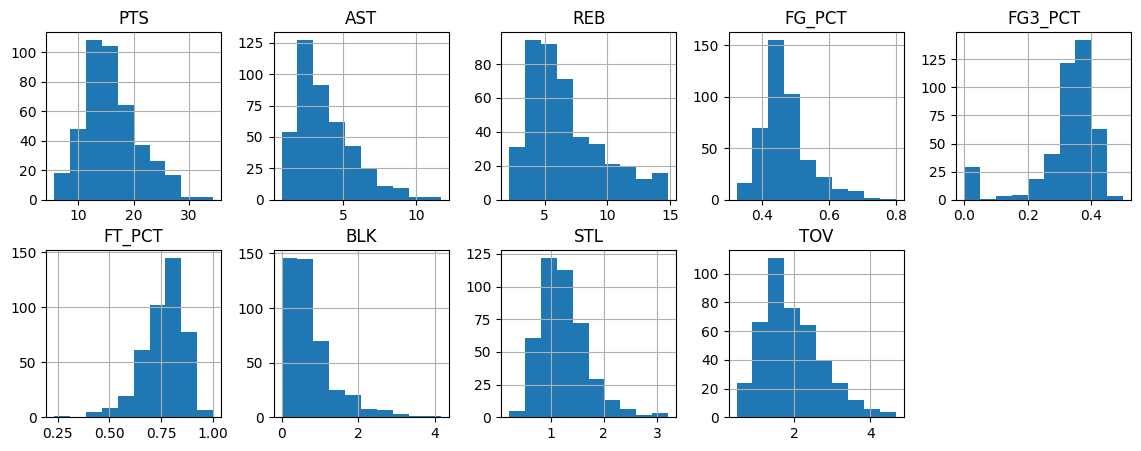

In [57]:
X.hist(figsize = (14,5),layout = (-1,5))

In [58]:
X.describe()

,PTS,AST,REB,FG_PCT,FG3_PCT,FT_PCT,BLK,STL,TOV
count,426.000000,426.000000,426.000000,426.000000,426.000000,426.000000,426.000000,426.000000,426.000000
mean,15.982911,3.729718,6.680939,0.467869,0.322885,0.764962,0.766784,1.236620,1.947418
std,5.009740,1.921137,2.959928,0.070953,0.104179,0.101259,0.623368,0.449206,0.788429
min,5.590000,0.740000,2.150000,0.323000,0.000000,0.233000,0.000000,0.220000,0.480000
25%,12.465000,2.220000,4.472500,0.424000,0.309250,0.710000,0.340000,0.920000,1.382500
50%,15.175000,3.260000,5.920000,0.457000,0.349000,0.779000,0.575000,1.160000,1.770000
75%,19.040000,4.762500,8.345000,0.497000,0.382000,0.832500,1.010000,1.460000,2.390000
max,34.430000,11.700000,14.870000,0.798000,0.500000,1.000000,4.150000,3.210000,4.670000


In [59]:
X.var()

,0
PTS,25.097497
AST,3.690767
REB,8.761175
FG_PCT,0.005034
FG3_PCT,0.010853
FT_PCT,0.010253
BLK,0.388588
STL,0.201786
TOV,0.621620


In [60]:
X.skew()

,0
PTS,0.671666
AST,1.164543
REB,0.985930
FG_PCT,1.200212
FG3_PCT,-2.004119
FT_PCT,-1.057542
BLK,1.821275
STL,1.131476
TOV,0.813481


In [61]:
X.kurt()

,0
PTS,0.284183
AST,1.346547
REB,0.227623
FG_PCT,2.332183
FG3_PCT,3.818986
FT_PCT,2.344641
BLK,4.048377
STL,2.223470
TOV,0.487479


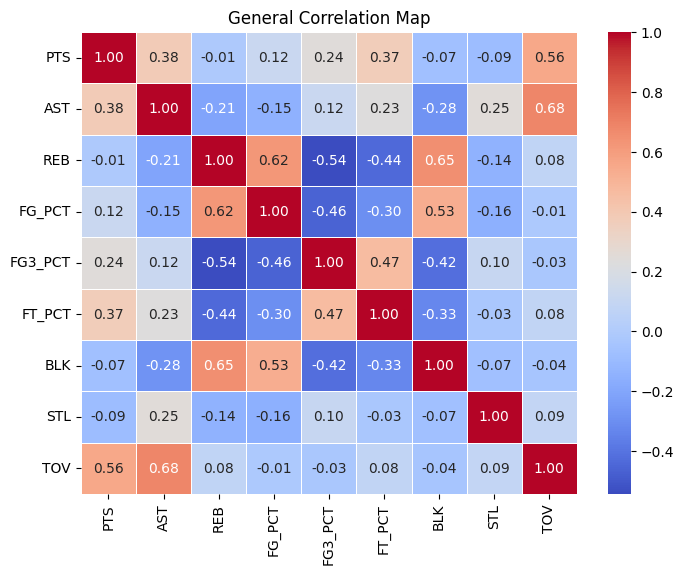

In [62]:
corr_matrix = X.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("General Correlation Map")
plt.show()

In [63]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
#raw_variance = np.var(X, axis=0)
#scaled_variance = np.var(X_scaled, axis=0)



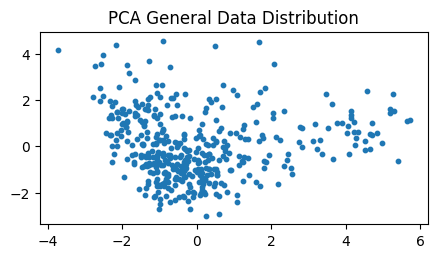

In [64]:
pca = PCA(n_components=2)
Z = pca.fit_transform(X_scaled)

plt.figure(figsize=(5,2.5))
plt.scatter(Z[:,0], Z[:,1], s=10)
plt.title("PCA General Data Distribution")
plt.show()

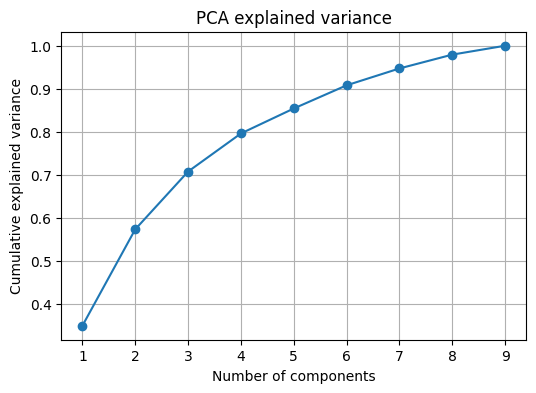

,k,silhouette,calinski_harabasz,davies_bouldin
0,2,0.354685,138.744340,1.357192
1,3,0.239822,137.608991,1.445459
2,4,0.231876,119.548159,1.470347
3,5,0.199674,109.824239,1.496563
4,6,0.186146,98.689581,1.618093
5,7,0.163046,90.162064,1.700110
6,8,0.162310,82.921664,1.707129
7,9,0.158474,79.065984,1.706727
8,10,0.159737,74.482032,1.585548


,covariance_type,k,bic,aic,silhouette,calinski_harabasz,davies_bouldin,avg_max_prob
9,diag,2,9734.326708,9584.312452,0.298103,132.861588,1.553340,0.980439
10,diag,3,9426.677476,9199.628872,0.219137,129.686980,1.488211,0.945322
11,diag,4,9315.291631,9011.208680,0.222344,117.053742,1.496256,0.946605
12,diag,5,9216.984351,8835.867052,0.162278,96.896811,1.695044,0.925772
13,diag,6,8969.516906,8511.365260,0.125733,82.893990,1.930034,0.898310
14,diag,7,8883.208790,8348.022797,0.122002,75.520480,1.874955,0.913835
15,diag,8,8936.412080,8324.191739,0.121638,68.515667,1.880445,0.911373
16,diag,9,8961.353926,8272.099237,0.109665,65.664235,1.830550,0.902879
17,diag,10,9016.389958,8250.100921,0.103582,63.615009,1.921706,0.887409
0,full,2,9069.392579,8627.458690,0.313736,133.915922,1.511754,0.979125


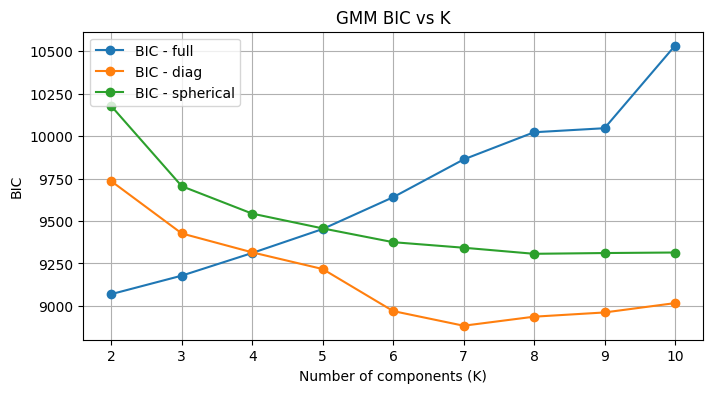

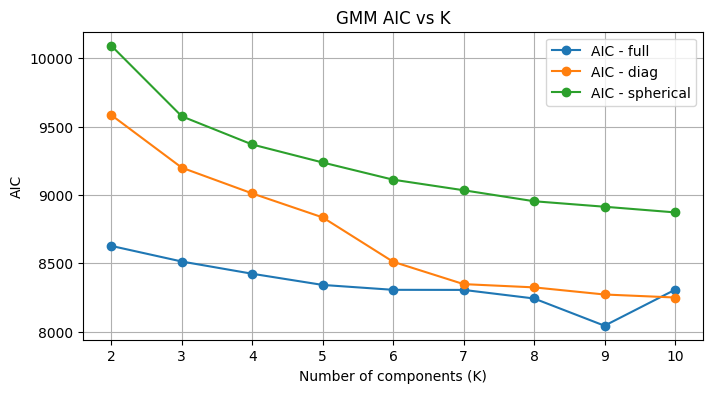

In [65]:
# trial and error part
pca = PCA(n_components=9)
pca.fit(X_scaled)
explained_var = pca.explained_variance_ratio_
cum_explained = np.cumsum(explained_var)
plt.figure(figsize=(6, 4))
plt.plot(range(1, len(explained_var) + 1), cum_explained, marker="o")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA explained variance")
plt.grid(True)
plt.show()
X_pca2 = pca.transform(X_scaled)[:, :2]
k_range = range(2, 11)
km_results = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)

    sil = silhouette_score(X_scaled, labels)
    ch = calinski_harabasz_score(X_scaled, labels)
    db = davies_bouldin_score(X_scaled, labels)

    km_results.append({
        "k": k,
        "silhouette": sil,
        "calinski_harabasz": ch,
        "davies_bouldin": db
    })

km_results_df = pd.DataFrame(km_results)
display(km_results_df)
k_range = range(2, 11)
cov_types = ["full", "diag","spherical"]

gmm_results = []

for cov in cov_types:
    for k in k_range:
        gmm = GaussianMixture(
            n_components=k,
            covariance_type=cov,
            n_init=10,
            reg_covar=1e-5,
            max_iter=500,
            init_params="kmeans",
            random_state=42)
        gmm.fit(X_scaled)
        labels = gmm.predict(X_scaled)
        probs = gmm.predict_proba(X_scaled)
        bic = gmm.bic(X_scaled)
        aic = gmm.aic(X_scaled)
        sil = silhouette_score(X_scaled, labels)
        ch = calinski_harabasz_score(X_scaled, labels)
        db = davies_bouldin_score(X_scaled, labels)
        avg_max_prob = probs.max(axis=1).mean()

        gmm_results.append({
            "covariance_type": cov,
            "k": k,
            "bic": bic,
            "aic": aic,
            "silhouette": sil,
            "calinski_harabasz": ch,
            "davies_bouldin": db,
            "avg_max_prob": avg_max_prob})

gmm_results_df = pd.DataFrame(gmm_results)
display(gmm_results_df.sort_values(["covariance_type", "k"]))
plt.figure(figsize=(8, 4))
for cov in cov_types:
    mask = gmm_results_df["covariance_type"] == cov
    sub = gmm_results_df[mask]
    plt.plot(sub["k"], sub["bic"], marker="o", label=f"BIC - {cov}")
plt.xlabel("Number of components (K)")
plt.ylabel("BIC")
plt.title("GMM BIC vs K")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
for cov in cov_types:
    mask = gmm_results_df["covariance_type"] == cov
    sub = gmm_results_df[mask]
    plt.plot(sub["k"], sub["aic"], marker="o", label=f"AIC - {cov}")
plt.xlabel("Number of components (K)")
plt.ylabel("AIC")
plt.title("GMM AIC vs K")
plt.legend()
plt.grid(True)
plt.show()


In [66]:
gmm_final = GaussianMixture(
    n_components=8,
    covariance_type='diag',
    n_init=10,
    reg_covar=1e-5,
    max_iter=500,
    init_params="kmeans",random_state=42)

gmm_final.fit(X_scaled)

cluster_labels = gmm_final.predict(X_scaled)
cluster_probs = gmm_final.predict_proba(X_scaled)
general["cluster"] = cluster_labels
general[[f"cluster_prob_{k}" for k in range(8)]] = cluster_probs


In [67]:
cluster_means_std = pd.DataFrame(
    gmm_final.means_,
    columns=features)
cluster_means_std.index.name = "cluster"
cluster_means_original = pd.DataFrame(
    scaler.inverse_transform(gmm_final.means_),
    columns=features
)
cluster_means_original.index.name = "cluster"
cluster_weights = pd.Series(gmm_final.weights_, index=cluster_means_std.index, name="weight")
cluster_counts = general["cluster"].value_counts().sort_index()
cluster_avg_max_prob = pd.Series(
    cluster_probs.max(axis=1)
).groupby(general["cluster"]).mean()
cluster_avg_max_prob.name = "avg_max_prob"

summary_overview = pd.concat(
    [cluster_weights, cluster_counts.rename("count"), cluster_avg_max_prob],
    axis=1
)

display(cluster_means_std)
display(cluster_means_original)
display(summary_overview)


,PTS,AST,REB,FG_PCT,FG3_PCT,FT_PCT,BLK,STL,TOV
cluster,,,,,,,,,
0,-0.374607,-0.834921,-0.530759,-0.353574,0.495549,0.282180,-0.444940,-0.408363,-0.971315
1,-0.590271,-0.639544,1.814839,2.147141,-3.102966,-1.465071,1.404730,-0.798016,-0.206699
2,1.259625,1.034138,0.677496,0.307772,0.150169,0.025564,0.096157,0.127885,1.487447
3,-0.767500,-0.246314,-0.282741,-0.628915,-0.012570,-0.216490,-0.246863,0.580003,-0.337025
4,0.660916,-0.375515,0.725975,0.290933,0.380671,0.094721,0.922022,-0.502104,-0.009196
5,0.557305,0.701801,-0.730821,-0.283241,0.441254,0.645496,-0.659296,-0.009168,0.382225
6,0.455693,2.429999,-0.423417,-0.558397,-0.351579,-0.089721,-0.503433,0.666649,2.396264
7,-0.512114,-0.642264,1.273947,1.012589,-0.322320,-0.888317,1.407987,0.266535,-0.319878


,PTS,AST,REB,FG_PCT,FG3_PCT,FT_PCT,BLK,STL,TOV
cluster,,,,,,,,,
0,14.108429,2.127604,5.111775,0.442811,3.744503e-01,0.793502,0.489748,1.053396,1.182504
1,13.029278,2.502510,12.046424,0.620036,2.775558e-16,0.616785,1.641420,0.878568,1.784642
2,22.285893,5.714106,8.683923,0.489680,3.385111e-01,0.767548,0.826655,1.293999,3.118787
3,12.142453,3.257071,5.845028,0.423298,3.215770e-01,0.743067,0.613078,1.496854,1.682010
4,19.290039,3.009150,8.827248,0.488487,3.624964e-01,0.774543,1.340868,1.011337,1.940176
5,18.771584,5.076391,4.520301,0.447795,3.688005e-01,0.830248,0.356283,1.232506,2.248421
6,18.263132,8.392596,5.429126,0.428295,2.863008e-01,0.755888,0.453329,1.535731,3.834482
7,13.420365,2.497291,10.447303,0.539630,2.893454e-01,0.675118,1.643448,1.356208,1.695513


,weight,count,avg_max_prob
cluster,,,
0.0,0.181176,81,0.928586
1.0,0.065727,28,0.844428
2.0,0.072534,30,0.945269
3.0,0.204852,81,0.914798
4.0,0.094268,37,0.911925
5.0,0.253985,113,0.911397
6.0,0.035077,15,0.930651
7.0,0.092382,41,0.932835


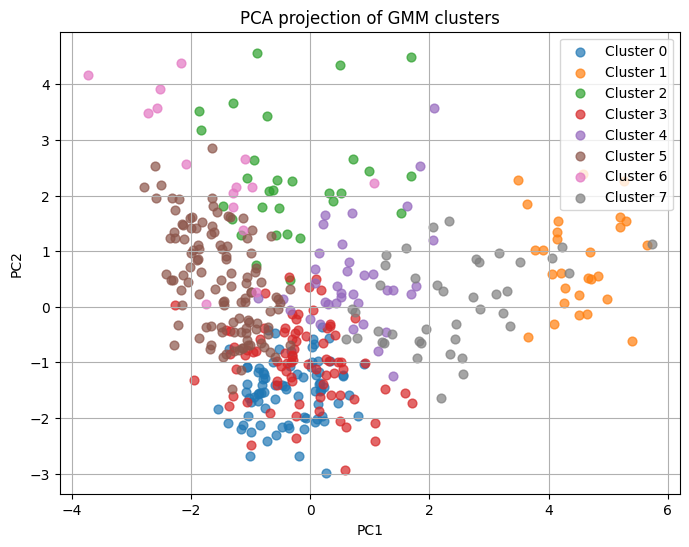

In [68]:
pca_vis = PCA(n_components=2)
X_pca_vis = pca_vis.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
palette = sns.color_palette("tab10", 8)

for k in range(8):
    mask = (cluster_labels == k)
    plt.scatter(
        X_pca_vis[mask, 0],
        X_pca_vis[mask, 1],
        s=40,
        alpha=0.7,
        color=palette[k],
        label=f"Cluster {k}"
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA projection of GMM clusters")
plt.legend()
plt.grid(True)
plt.show()


In [69]:
def top_players_in_cluster(df, cluster_id, prob_matrix, top_n=10, player_col="PLAYER_NAME"):
    probs = prob_matrix[:, cluster_id]
    df_temp = df.copy()
    df_temp["cluster_prob"] = probs
    return (
        df_temp[df_temp["cluster"] == cluster_id]
        .sort_values("cluster_prob", ascending=False)
        [[player_col, "cluster", "cluster_prob"] + features]
        .head(top_n))

for k in range(8):
    print(f"\n=== Cluster {k} ===")
    display(top_players_in_cluster(general, k, cluster_probs))



=== Cluster 0 ===


,PLAYER_NAME,cluster,cluster_prob,PTS,AST,REB,FG_PCT,FG3_PCT,FT_PCT,BLK,STL,TOV
480,Sam Hauser,0,0.998215,14.13,1.50,5.23,0.451,0.416,1.000,0.30,0.96,0.54
21,Amir Coffey,0,0.995840,14.34,1.59,3.32,0.471,0.409,0.891,0.14,0.82,0.93
354,Landry Shamet,0,0.995748,13.52,1.28,2.88,0.461,0.397,0.667,0.09,1.09,1.04
243,Jamison Battle,0,0.995576,14.48,1.83,5.46,0.429,0.405,0.889,0.35,0.59,0.93
515,Tim Hardaway Jr.,0,0.994920,14.11,2.06,3.06,0.406,0.368,0.855,0.12,0.64,0.80
476,Rui Hachimura,0,0.994387,14.93,1.60,5.68,0.509,0.413,0.770,0.50,0.87,0.94
1,AJ Green,0,0.994267,11.74,2.34,3.78,0.429,0.427,0.815,0.15,0.80,0.87
70,Caleb Houstan,0,0.993899,10.92,1.60,3.43,0.421,0.400,0.882,0.27,1.01,0.59
5,Aaron Nesmith,0,0.993546,17.36,1.73,5.71,0.507,0.431,0.913,0.55,1.12,1.19
111,Dalton Knecht,0,0.992947,17.01,1.59,5.21,0.461,0.376,0.762,0.19,0.58,0.89



=== Cluster 1 ===


,PLAYER_NAME,cluster,cluster_prob,PTS,AST,REB,FG_PCT,FG3_PCT,FT_PCT,BLK,STL,TOV
533,Tristan Thompson,1,1.000000,7.57,2.63,14.70,0.437,0.0,0.233,1.21,0.22,1.54
129,DeAndre Jordan,1,1.000000,10.89,2.76,14.80,0.650,0.0,0.422,1.41,0.83,2.08
530,Trey Jemison III,1,1.000000,8.72,1.47,9.64,0.554,0.0,0.394,1.38,0.83,2.20
44,Bismack Biyombo,1,1.000000,9.83,2.12,10.78,0.588,0.0,0.400,1.57,1.09,1.84
269,Jericho Sims,1,0.999999,5.59,1.88,11.23,0.634,0.0,0.615,1.08,0.57,1.88
499,Steven Adams,1,0.999999,10.20,2.99,14.82,0.545,0.0,0.462,1.27,1.00,2.45
382,Mark Williams,1,0.999999,20.63,3.35,13.74,0.604,0.0,0.804,1.66,0.98,2.18
226,Jalen Duren,1,0.999998,16.25,3.70,14.29,0.692,0.0,0.669,1.58,0.96,2.41
203,Ivica Zubac,1,0.999998,18.38,2.94,13.86,0.628,0.0,0.661,1.23,0.75,1.74
387,Mason Plumlee,1,0.999997,9.22,3.71,12.60,0.619,0.0,0.648,1.30,0.91,1.63



=== Cluster 2 ===


...

,PLAYER_NAME,cluster,cluster_prob,PTS,AST,REB,FG_PCT,FG3_PCT,FT_PCT,BLK,STL,TOV
26,Anfernee Simons,5,0.999923,21.17,5.29,2.97,0.426,0.363,0.902,0.08,0.94,2.25
237,Jamal Murray,5,0.999918,21.38,6.00,3.89,0.474,0.393,0.886,0.49,1.35,2.05
546,Tyus Jones,5,0.999865,13.73,7.11,3.25,0.448,0.414,0.895,0.13,1.14,1.51
192,Immanuel Quickley,5,0.999855,22.12,7.49,4.59,0.420,0.378,0.867,0.16,0.90,2.28
91,Coby White,5,0.999752,22.17,4.85,4.01,0.453,0.370,0.902,0.24,1.01,2.60
36,Austin Reaves,5,0.999748,20.82,5.94,4.64,0.460,0.377,0.877,0.31,1.14,2.50
380,Marcus Sasser,5,0.999698,16.65,5.91,3.06,0.463,0.382,0.843,0.18,1.64,2.40
136,Dennis Schröder,5,0.999636,16.76,6.91,3.39,0.406,0.342,0.838,0.21,1.13,2.43
350,Kyrie Irving,5,0.999604,24.63,4.61,4.79,0.473,0.401,0.916,0.46,1.32,2.22
524,Tre Jones,5,0.999601,13.13,7.64,4.61,0.538,0.396,0.821,0.40,1.47,1.39



=== Cluster 6 ===


,PLAYER_NAME,cluster,cluster_prob,PTS,AST,REB,FG_PCT,FG3_PCT,FT_PCT,BLK,STL,TOV
163,Elfrid Payton,6,1.000000,5.99,11.70,5.57,0.328,0.167,0.571,0.78,1.69,4.16
41,Ben Simmons,6,0.999967,8.23,9.16,7.75,0.520,0.000,0.727,0.74,1.22,3.28
195,Isaiah Collier,6,0.999842,12.04,8.73,4.60,0.422,0.249,0.682,0.31,1.29,4.07
522,Trae Young,6,0.999780,24.20,11.57,3.10,0.411,0.340,0.875,0.16,1.20,4.67
470,Rob Dillingham,6,0.997133,15.28,6.84,3.49,0.441,0.338,0.533,0.07,1.40,3.70
240,James Harden,6,0.997048,23.26,8.87,5.89,0.410,0.352,0.874,0.71,1.52,4.40
69,Cade Cunningham,6,0.993115,26.87,9.37,6.24,0.469,0.356,0.846,0.78,1.04,4.54
206,Ja Morant,6,0.992987,27.47,8.63,4.86,0.454,0.309,0.824,0.28,1.45,4.38
477,Russell Westbrook,6,0.992156,17.10,7.86,6.37,0.449,0.323,0.661,0.64,1.82,4.16
133,Dejounte Murray,6,0.987712,19.28,8.11,7.11,0.393,0.299,0.823,0.43,2.24,3.77



=== Cluster 7 ===


,PLAYER_NAME,cluster,cluster_prob,PTS,AST,REB,FG_PCT,FG3_PCT,FT_PCT,BLK,STL,TOV
553,Walker Kessler,7,1.000000,13.26,2.01,14.62,0.663,0.176,0.520,2.85,0.74,1.78
181,Goga Bitadze,7,1.000000,12.64,3.45,11.66,0.611,0.107,0.639,2.47,1.23,1.81
312,Kai Jones,7,1.000000,15.22,1.92,9.61,0.798,0.200,0.719,1.77,1.15,1.38
55,Brandon Clarke,7,1.000000,15.93,1.97,9.72,0.621,0.059,0.701,1.07,1.55,1.22
283,Jonathan Isaac,7,1.000000,12.55,1.32,10.37,0.414,0.258,0.682,2.64,2.01,1.09
417,Nic Claxton,7,1.000000,13.85,3.00,9.85,0.563,0.238,0.513,1.91,1.19,1.66
450,Paul Reed,7,1.000000,15.14,3.62,10.12,0.507,0.286,0.762,2.06,3.21,2.14
15,Alex Len,7,1.000000,7.01,3.60,9.00,0.508,0.222,0.471,1.99,0.85,1.90
160,Dwight Powell,7,0.999999,7.45,3.59,7.71,0.689,0.400,0.651,1.37,1.18,1.18
408,Mouhamed Gueye,7,0.999999,13.31,1.82,9.39,0.421,0.259,0.762,2.23,1.89,1.01


In [70]:
role_labels = {
    0: "Off Ball Spacers",
    1: "Traditional  Big",
    2: "All Around Offensive Engine",
    3: "Two-Way Guard",
    4: "Modern Big",
    5: "Shot Creating Guard",
    6: "High Usage Playmaker",
    7: "Rim Protecting Big"}

general["role_label"] = general["cluster"].map(role_labels)


In [71]:
means = general.groupby("role_label")[["PTS", "AST", "REB", "FG_PCT", "FG3_PCT", "FT_PCT", "BLK", "STL", "TOV"]].mean()
means

,PTS,AST,REB,FG_PCT,FG3_PCT,FT_PCT,BLK,STL,TOV
role_label,,,,,,,,,
All Around Offensive Engine,22.453333,5.755000,8.888333,0.490533,0.341133,0.767400,0.845333,1.279667,3.129000
High Usage Playmaker,17.808000,8.381333,5.350667,0.428533,0.279733,0.750533,0.438000,1.576667,3.804000
Modern Big,19.411351,2.991081,8.834595,0.487432,0.362000,0.773162,1.391351,1.022973,1.936216
Off Ball Spacers,14.136049,2.116049,5.159877,0.442654,0.375259,0.795494,0.494815,1.044815,1.181481
Rim Protecting Big,13.511707,2.523902,10.484634,0.539756,0.290366,0.677854,1.631220,1.357073,1.697805
Shot Creating Guard,18.798496,5.063274,4.549646,0.449009,0.369115,0.828805,0.360796,1.225752,2.251681
Traditional Big,13.029286,2.502500,12.046429,0.620036,0.000000,0.616786,1.641429,0.878571,1.784643
Two-Way Guard,11.873210,3.243457,5.840247,0.420358,0.317457,0.738704,0.611728,1.525062,1.695185


# **Shooting Analysis**

In [72]:
features = ['FG_PCT', 'FG3_PCT', 'FT_PCT','CATCH_SHOOT_PCT', 'DRIVE_PCT', 'PULL_UP_PCT','PAINT_TOUCH_PCT', 'POST_TOUCH_PCT', 'ELBOW_TOUCH_PCT']
X = shoot[features]

array([[<Axes: title={'center': 'FG_PCT'}>,
        <Axes: title={'center': 'FG3_PCT'}>,
        <Axes: title={'center': 'FT_PCT'}>,
        <Axes: title={'center': 'CATCH_SHOOT_PCT'}>,
        <Axes: title={'center': 'DRIVE_PCT'}>],
       [<Axes: title={'center': 'PULL_UP_PCT'}>,
        <Axes: title={'center': 'PAINT_TOUCH_PCT'}>,
        <Axes: title={'center': 'POST_TOUCH_PCT'}>,
        <Axes: title={'center': 'ELBOW_TOUCH_PCT'}>, <Axes: >]],
      dtype=object)

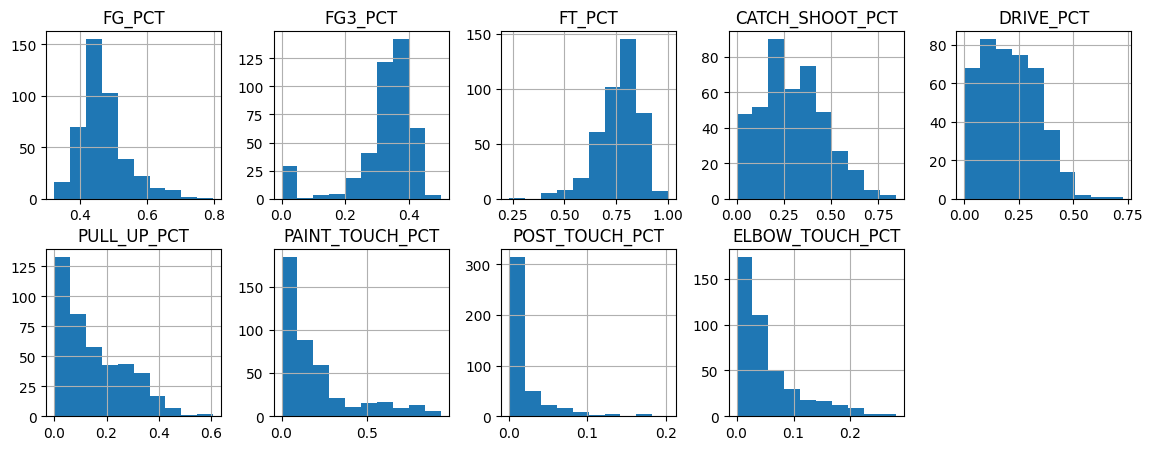

In [73]:
X.hist(figsize = (14,5),layout = (-1,5))

In [74]:
X.describe()

,FG_PCT,FG3_PCT,FT_PCT,CATCH_SHOOT_PCT,DRIVE_PCT,PULL_UP_PCT,PAINT_TOUCH_PCT,POST_TOUCH_PCT,ELBOW_TOUCH_PCT
count,426.000000,426.000000,426.000000,426.000000,426.000000,426.000000,426.000000,426.000000,426.000000
mean,0.467869,0.322885,0.764962,0.297279,0.210185,0.149465,0.200489,0.017167,0.056174
std,0.070953,0.104179,0.101259,0.171177,0.128158,0.126229,0.215715,0.031887,0.055407
min,0.323000,0.000000,0.233000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.424000,0.309250,0.710000,0.176957,0.097900,0.043478,0.049304,0.000000,0.017804
50%,0.457000,0.349000,0.779000,0.273069,0.199611,0.114339,0.117284,0.001816,0.036170
75%,0.497000,0.382000,0.832500,0.414888,0.304630,0.242667,0.253105,0.022119,0.075906
max,0.798000,0.500000,1.000000,0.843447,0.729549,0.606514,0.928375,0.202938,0.279279


In [75]:
X.var()

,0
FG_PCT,0.005034
FG3_PCT,0.010853
FT_PCT,0.010253
CATCH_SHOOT_PCT,0.029301
DRIVE_PCT,0.016425
PULL_UP_PCT,0.015934
PAINT_TOUCH_PCT,0.046533
POST_TOUCH_PCT,0.001017
ELBOW_TOUCH_PCT,0.003070


In [76]:
X.skew()

,0
FG_PCT,1.200212
FG3_PCT,-2.004119
FT_PCT,-1.057542
CATCH_SHOOT_PCT,0.369062
DRIVE_PCT,0.454412
PULL_UP_PCT,0.780919
PAINT_TOUCH_PCT,1.551709
POST_TOUCH_PCT,2.876096
ELBOW_TOUCH_PCT,1.592422


In [77]:
X.kurt()

,0
FG_PCT,2.332183
FG3_PCT,3.818986
FT_PCT,2.344641
CATCH_SHOOT_PCT,-0.245910
DRIVE_PCT,-0.118510
PULL_UP_PCT,-0.155003
PAINT_TOUCH_PCT,1.468353
POST_TOUCH_PCT,9.694387
ELBOW_TOUCH_PCT,2.209050


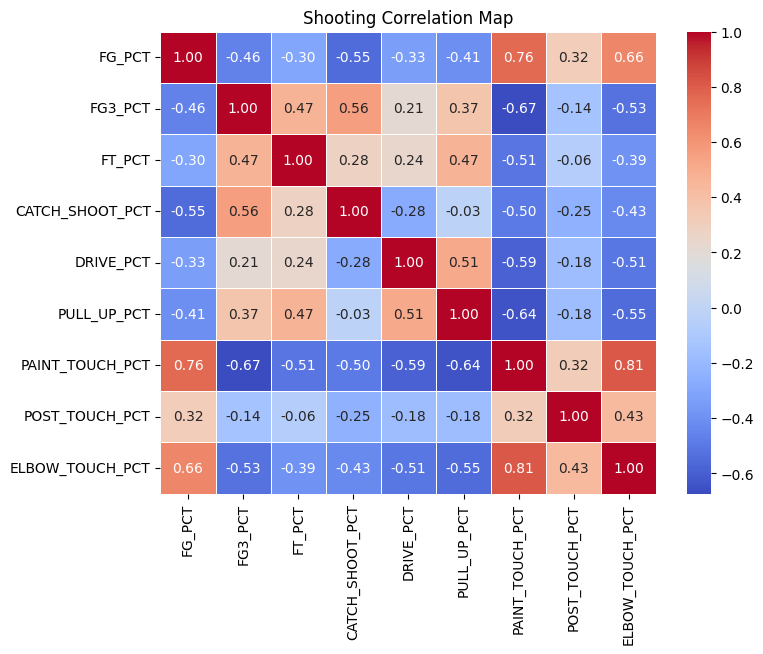

In [78]:
corr_matrix = X.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Shooting Correlation Map")
plt.show()

In [79]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
#raw_variance = np.var(X, axis=0)
#scaled_variance = np.var(X_scaled, axis=0)


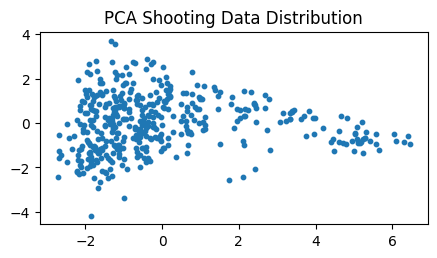

In [80]:
pca = PCA(n_components=2)
Z = pca.fit_transform(X_scaled)

plt.figure(figsize=(5,2.5))
plt.scatter(Z[:,0], Z[:,1], s=10)
plt.title("PCA Shooting Data Distribution")
plt.show()

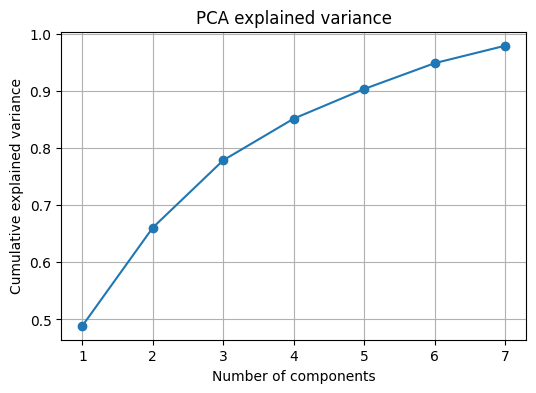

,k,silhouette,calinski_harabasz,davies_bouldin
0,2,0.444546,257.521924,1.046325
1,3,0.240533,207.300395,1.366338
2,4,0.249997,187.650243,1.319223
3,5,0.235089,171.098471,1.361608
4,6,0.235041,159.759261,1.361510
5,7,0.217549,148.097270,1.404773
6,8,0.218693,137.523542,1.311528
7,9,0.192305,128.124056,1.352664
8,10,0.193558,122.119921,1.338198


,covariance_type,k,bic,aic,silhouette,calinski_harabasz,davies_bouldin,avg_max_prob
9,diag,2,7318.902289,7201.323548,0.353373,195.001486,1.379741,0.956544
10,diag,3,7155.142054,6976.746722,0.162031,147.395651,1.641118,0.927192
11,diag,4,7061.838030,6822.626108,0.164408,132.158921,1.585501,0.920471
12,diag,5,7021.760980,6721.732469,0.165762,111.225737,1.800320,0.915595
13,diag,6,7029.335466,6668.490364,0.139340,107.937079,1.764001,0.893032
14,diag,7,7050.971056,6629.309364,0.140344,100.366378,1.853588,0.873761
15,diag,8,7075.131161,6592.652878,0.132508,101.416458,1.837284,0.880236
16,diag,9,7100.755159,6557.460287,0.132175,98.087490,1.920562,0.877427
17,diag,10,7112.569736,6508.458274,0.127449,87.824682,1.605758,0.889476
0,full,2,6908.479718,6620.614525,0.389205,229.308118,1.228445,0.982668


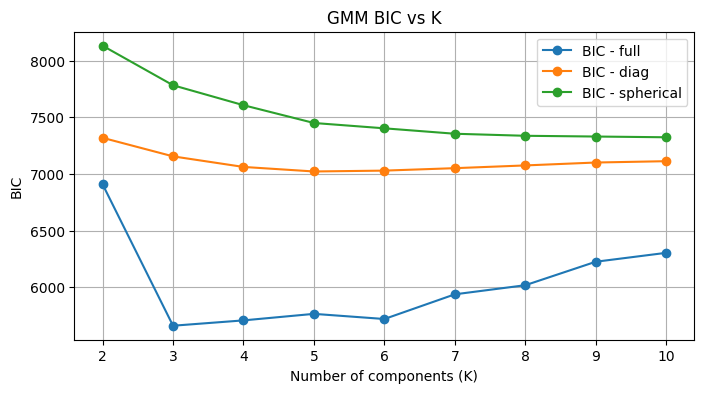

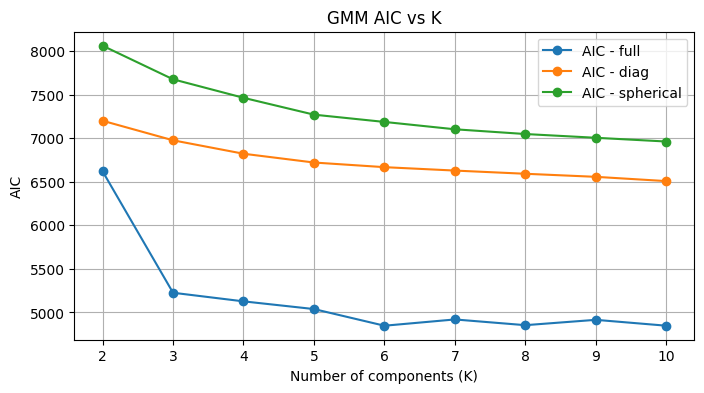

In [81]:
pca = PCA(n_components=0.95)
X_scaled = pca.fit_transform(X_scaled)

explained_var = pca.explained_variance_ratio_
cum_explained = np.cumsum(explained_var)

plt.figure(figsize=(6, 4))
plt.plot(range(1, len(explained_var) + 1), cum_explained, marker="o")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA explained variance")
plt.grid(True)
plt.show()

k_range = range(2, 11)
km_results = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)

    sil = silhouette_score(X_scaled, labels)
    ch = calinski_harabasz_score(X_scaled, labels)
    db = davies_bouldin_score(X_scaled, labels)

    km_results.append({
        "k": k,
        "silhouette": sil,
        "calinski_harabasz": ch,
        "davies_bouldin": db
    })
km_results_df = pd.DataFrame(km_results)
display(km_results_df)

k_range = range(2, 11)
cov_types = ["full", "diag","spherical"]

gmm_results = []

for cov in cov_types:
    for k in k_range:
        gmm = GaussianMixture(
            n_components=k,
            covariance_type=cov,
            n_init=10,
            reg_covar=1e-5,
            max_iter=500,
            init_params="kmeans",
            random_state=42)

        gmm.fit(X_scaled)
        labels = gmm.predict(X_scaled)
        probs = gmm.predict_proba(X_scaled)

        bic = gmm.bic(X_scaled)
        aic = gmm.aic(X_scaled)
        sil = silhouette_score(X_scaled, labels)
        ch = calinski_harabasz_score(X_scaled, labels)
        db = davies_bouldin_score(X_scaled, labels)
        avg_max_prob = probs.max(axis=1).mean()

        gmm_results.append({
            "covariance_type": cov,
            "k": k,
            "bic": bic,
            "aic": aic,
            "silhouette": sil,
            "calinski_harabasz": ch,
            "davies_bouldin": db,
            "avg_max_prob": avg_max_prob})

gmm_results_df = pd.DataFrame(gmm_results)
display(gmm_results_df.sort_values(["covariance_type", "k"]))

plt.figure(figsize=(8, 4))
for cov in cov_types:
    mask = gmm_results_df["covariance_type"] == cov
    sub = gmm_results_df[mask]
    plt.plot(sub["k"], sub["bic"], marker="o", label=f"BIC - {cov}")
plt.xlabel("Number of components (K)")
plt.ylabel("BIC")
plt.title("GMM BIC vs K")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
for cov in cov_types:
    mask = gmm_results_df["covariance_type"] == cov
    sub = gmm_results_df[mask]
    plt.plot(sub["k"], sub["aic"], marker="o", label=f"AIC - {cov}")
plt.xlabel("Number of components (K)")
plt.ylabel("AIC")
plt.title("GMM AIC vs K")
plt.legend()
plt.grid(True)
plt.show()


In [82]:
# model based on results
gmm_final = GaussianMixture(
    n_components=4,
    covariance_type='full',
    n_init=10,
    reg_covar=1e-5,
    max_iter=500,
    init_params="kmeans",
    random_state=42
)

gmm_final.fit(X_scaled)

cluster_labels = gmm_final.predict(X_scaled)
cluster_probs = gmm_final.predict_proba(X_scaled)
shoot["cluster"] = cluster_labels
shoot[[f"cluster_prob_{k}" for k in range(4)]] = cluster_probs

In [83]:
cluster_means_pca_space = pd.DataFrame(
    gmm_final.means_,
    columns=[f"PC{i+1}" for i in range(gmm_final.means_.shape[1])]
)
cluster_means_pca_space.index.name = "cluster"

scaled_means_original_features = pca.inverse_transform(gmm_final.means_)

cluster_means_std = pd.DataFrame(
    scaled_means_original_features,
    columns=features
)
cluster_means_std.index.name = "cluster"

cluster_means_original = pd.DataFrame(
    scaler.inverse_transform(scaled_means_original_features),
    columns=features
)
cluster_means_original.index.name = "cluster"

cluster_weights = pd.Series(gmm_final.weights_, index=cluster_means_std.index, name="weight")
cluster_counts = shoot["cluster"].value_counts().sort_index()
cluster_avg_max_prob = pd.Series(
    cluster_probs.max(axis=1)
).groupby(shoot["cluster"]).mean()
cluster_avg_max_prob.name = "avg_max_prob"

summary_overview = pd.concat(
    [cluster_weights, cluster_counts.rename("count"), cluster_avg_max_prob],
    axis=1
)

display(cluster_means_std)
display(cluster_means_original)
display(summary_overview)

,FG_PCT,FG3_PCT,FT_PCT,CATCH_SHOOT_PCT,DRIVE_PCT,PULL_UP_PCT,PAINT_TOUCH_PCT,POST_TOUCH_PCT,ELBOW_TOUCH_PCT
cluster,,,,,,,,,
0,-0.284607,0.358901,0.235202,0.046046,0.410610,0.556789,-0.489317,-0.088237,-0.475083
1,-0.507496,0.314337,0.225975,0.393134,0.233352,0.261708,-0.508412,-0.539152,-0.526242
2,0.215200,0.215351,0.123964,-0.057765,0.013851,-0.310679,0.095219,1.165256,0.276828
3,1.443886,-1.416671,-0.964676,-1.019362,-1.083011,-1.028661,1.786808,0.444029,1.652633


,FG_PCT,FG3_PCT,FT_PCT,CATCH_SHOOT_PCT,DRIVE_PCT,PULL_UP_PCT,PAINT_TOUCH_PCT,POST_TOUCH_PCT,ELBOW_TOUCH_PCT
cluster,,,,,,,,,
0,0.447699,0.360231,0.788751,0.305151,0.262747,0.219665,0.095059,0.014357,0.029882
1,0.431902,0.355594,0.787818,0.364495,0.240056,0.182461,0.090945,-0.000004,0.027051
2,0.483120,0.345294,0.777500,0.287402,0.211958,0.110294,0.221005,0.054280,0.071494
3,0.570196,0.175471,0.667395,0.122992,0.071551,0.019771,0.585478,0.031309,0.147634


,weight,count,avg_max_prob
cluster,,,
0,0.201276,88,0.932207
1,0.460499,198,0.988962
2,0.160638,66,0.919691
3,0.177588,74,0.988486


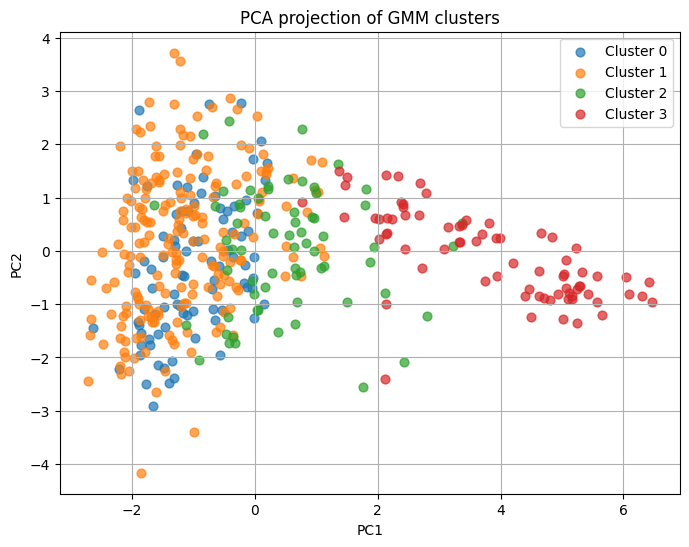

In [84]:
pca_vis = PCA(n_components=2)
X_pca_vis = pca_vis.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
palette = sns.color_palette("tab10", 4)

for k in range(4):
    mask = (cluster_labels == k)
    plt.scatter(
        X_pca_vis[mask, 0],
        X_pca_vis[mask, 1],
        s=40,
        alpha=0.7,
        color=palette[k],
        label=f"Cluster {k}"
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA projection of GMM clusters")
plt.legend()
plt.grid(True)
plt.show()


In [85]:
def top_players_in_cluster(df, cluster_id, prob_matrix, top_n=10, player_col="PLAYER_NAME"):
    probs = prob_matrix[:, cluster_id]
    df_temp = df.copy()
    df_temp["cluster_prob"] = probs
    return (
        df_temp[df_temp["cluster"] == cluster_id]
        .sort_values("cluster_prob", ascending=False)
        [[player_col, "cluster", "cluster_prob"] + features]
        .head(top_n)
    )

for k in range(4):
    print(f"\n=== Cluster {k} ===")
    display(top_players_in_cluster(shoot, k, cluster_probs))


=== Cluster 0 ===


,PLAYER_NAME,cluster,cluster_prob,FG_PCT,FG3_PCT,FT_PCT,CATCH_SHOOT_PCT,DRIVE_PCT,PULL_UP_PCT,PAINT_TOUCH_PCT,POST_TOUCH_PCT,ELBOW_TOUCH_PCT
67,Chris Paul,0,1.000000,0.427,0.377,0.924,0.213908,0.175176,0.606514,0.014965,0.007923,0.007923
24,Anthony Edwards,0,0.999990,0.447,0.395,0.837,0.124908,0.309890,0.411355,0.032601,0.006593,0.022344
53,CJ McCollum,0,0.999979,0.444,0.373,0.717,0.247742,0.325591,0.350108,0.019355,0.001720,0.015914
111,Devin Carter,0,0.999977,0.370,0.295,0.591,0.260558,0.253386,0.130677,0.152191,0.014343,0.014343
281,Luka Dončić,0,0.999957,0.450,0.368,0.782,0.104327,0.367062,0.395673,0.041870,0.024773,0.012910
181,Jamal Murray,0,0.999956,0.474,0.393,0.886,0.152479,0.304490,0.394294,0.055192,0.012629,0.025257
183,James Harden,0,0.999948,0.410,0.352,0.874,0.083405,0.382201,0.390800,0.015477,0.005589,0.006449
258,Kevin Porter Jr.,0,0.999932,0.449,0.311,0.769,0.085424,0.382808,0.410037,0.058195,0.002670,0.037373
56,Caleb Martin,0,0.999924,0.424,0.359,0.622,0.306084,0.297529,0.154943,0.090304,0.005703,0.022814
175,Jalen Pickett,0,0.999876,0.428,0.396,0.750,0.419981,0.174838,0.330250,0.064755,0.020352,0.024977



=== Cluster 1 ===


,PLAYER_NAME,cluster,cluster_prob,FG_PCT,FG3_PCT,FT_PCT,CATCH_SHOOT_PCT,DRIVE_PCT,PULL_UP_PCT,PAINT_TOUCH_PCT,POST_TOUCH_PCT,ELBOW_TOUCH_PCT
121,Doug McDermott,1,1.000000,0.427,0.436,0.600,0.836669,0.000000,0.088444,0.034216,0.0,0.000000
388,Tidjane Salaün,1,0.999986,0.330,0.283,0.713,0.351616,0.184133,0.161606,0.136141,0.0,0.042116
73,Cody Williams,1,0.999928,0.323,0.259,0.725,0.444302,0.261204,0.056338,0.083227,0.0,0.025608
336,Patty Mills,1,0.999909,0.375,0.347,0.929,0.486356,0.036116,0.324238,0.036116,0.0,0.044944
414,Vít Krejčí,1,0.999876,0.497,0.437,0.711,0.536131,0.148407,0.157731,0.053613,0.0,0.014763
91,Danté Exum,1,0.999871,0.478,0.434,0.742,0.362069,0.344828,0.114744,0.057669,0.0,0.011296
10,Alec Burks,1,0.999860,0.424,0.425,0.776,0.590296,0.143531,0.216307,0.008760,0.0,0.000000
129,Eric Gordon,1,0.999831,0.426,0.409,0.750,0.582665,0.247994,0.086677,0.015249,0.0,0.015249
411,Vasilije Micic,1,0.999803,0.348,0.360,0.829,0.196921,0.334684,0.445705,0.014587,0.0,0.007293
100,Dean Wade,1,0.999777,0.413,0.360,0.533,0.721739,0.071739,0.031522,0.093478,0.0,0.021739



=== Cluster 2 ===


,PLAYER_NAME,cluster,cluster_prob,FG_PCT,FG3_PCT,FT_PCT,CATCH_SHOOT_PCT,DRIVE_PCT,PULL_UP_PCT,PAINT_TOUCH_PCT,POST_TOUCH_PCT,ELBOW_TOUCH_PCT
390,Tobias Harris,2,1.0,0.477,0.345,0.861,0.271565,0.195527,0.189776,0.135463,0.134824,0.056869
38,Bobby Portis,2,1.0,0.466,0.365,0.836,0.333841,0.072154,0.169207,0.246951,0.133638,0.055894
210,Joel Embiid,2,1.0,0.444,0.299,0.882,0.194846,0.252030,0.174726,0.152489,0.150371,0.099541
333,Pascal Siakam,2,1.0,0.519,0.389,0.734,0.248879,0.194619,0.164126,0.220628,0.124664,0.077130
30,Bam Adebayo,2,1.0,0.485,0.357,0.765,0.218651,0.184405,0.184932,0.276080,0.059009,0.141728
261,Khris Middleton,2,1.0,0.475,0.361,0.857,0.179351,0.170303,0.458755,0.040979,0.093135,0.006919
140,Giannis Antetokounmpo,2,1.0,0.601,0.222,0.617,0.008430,0.294099,0.155791,0.229785,0.082111,0.090228
99,DeMar DeRozan,2,1.0,0.477,0.328,0.857,0.154227,0.294964,0.429856,0.032824,0.102518,0.031475
425,Zion Williamson,2,1.0,0.567,0.231,0.656,0.008078,0.503393,0.036511,0.214216,0.062359,0.080129
397,Trendon Watford,2,1.0,0.469,0.330,0.762,0.166761,0.495775,0.061972,0.099718,0.089014,0.004507



=== Cluster 3 ===


,PLAYER_NAME,cluster,cluster_prob,FG_PCT,FG3_PCT,FT_PCT,CATCH_SHOOT_PCT,DRIVE_PCT,PULL_UP_PCT,PAINT_TOUCH_PCT,POST_TOUCH_PCT,ELBOW_TOUCH_PCT
7,Adem Bona,3,1.0,0.703,0.000,0.670,0.000000,0.097688,0.000000,0.664430,0.032811,0.094705
69,Christian Koloko,3,1.0,0.606,0.000,0.714,0.000000,0.022129,0.022129,0.699684,0.044257,0.066386
44,Brandon Clarke,3,1.0,0.621,0.059,0.701,0.061519,0.099184,0.022599,0.569366,0.003766,0.188952
64,Charles Bassey,3,1.0,0.581,0.000,0.636,0.063787,0.025249,0.012625,0.815282,0.031894,0.127575
36,Bismack Biyombo,3,1.0,0.588,0.000,0.400,0.000000,0.000000,0.000000,0.756867,0.041709,0.152594
154,Isaiah Hartenstein,3,1.0,0.581,0.000,0.675,0.209979,0.054747,0.028413,0.638947,0.006237,0.279279
98,DeAndre Jordan,3,1.0,0.650,0.000,0.422,0.000000,0.000000,0.000000,0.928375,0.028466,0.129477
106,Dereck Lively II,3,1.0,0.702,0.000,0.630,0.012528,0.028740,0.000000,0.825350,0.025792,0.168755
89,Daniel Gafford,3,1.0,0.702,0.000,0.689,0.005831,0.078231,0.002915,0.746356,0.058309,0.139942
70,Clint Capela,3,1.0,0.559,0.000,0.536,0.004019,0.012056,0.000000,0.844608,0.030810,0.149364


In [86]:
role_labels_passing = {
    0: "3-Level Shooter",
    1: "Catch-and-Shooter",
    2: "Mid-Range Forward",
    3: "Interior Finisher"
}

shoot["role_label"] = shoot["cluster"].map(role_labels_passing)

In [87]:
means = shoot.groupby("role_label")[['FG_PCT', 'FG3_PCT', 'FT_PCT','CATCH_SHOOT_PCT', 'DRIVE_PCT', 'PULL_UP_PCT','PAINT_TOUCH_PCT', 'POST_TOUCH_PCT', 'ELBOW_TOUCH_PCT']].mean()
means

,FG_PCT,FG3_PCT,FT_PCT,CATCH_SHOOT_PCT,DRIVE_PCT,PULL_UP_PCT,PAINT_TOUCH_PCT,POST_TOUCH_PCT,ELBOW_TOUCH_PCT
role_label,,,,,,,,,
3-Level Shooter,0.448523,0.360795,0.788409,0.306342,0.259965,0.212262,0.093360,0.014504,0.030246
Catch-and-Shooter,0.432995,0.354318,0.787455,0.367145,0.241669,0.183214,0.088547,0.000000,0.027978
Interior Finisher,0.569270,0.174716,0.666284,0.113883,0.070267,0.019024,0.612748,0.031326,0.146789
Mid-Range Forward,0.484591,0.344167,0.776864,0.281218,0.206239,0.110739,0.216921,0.056345,0.073734


---

# **Playmaking Analysis**

In [88]:
features = ['AST','SECONDARY_AST', 'DRIVE_AST', 'SCREEN_ASSISTS','TOV', 'PFD', 'FT_AST', 'AST_TO_PASS_PCT_ADJ']

X = passing[features]

array([[<Axes: title={'center': 'AST'}>,
        <Axes: title={'center': 'SECONDARY_AST'}>,
        <Axes: title={'center': 'DRIVE_AST'}>,
        <Axes: title={'center': 'SCREEN_ASSISTS'}>],
       [<Axes: title={'center': 'TOV'}>, <Axes: title={'center': 'PFD'}>,
        <Axes: title={'center': 'FT_AST'}>,
        <Axes: title={'center': 'AST_TO_PASS_PCT_ADJ'}>]], dtype=object)

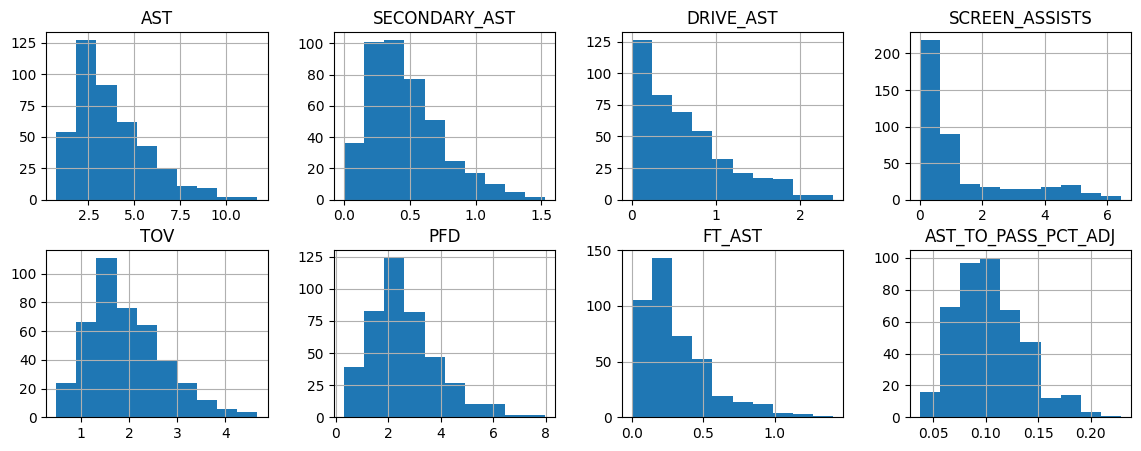

In [89]:
X.hist(figsize = (14,5),layout = (-1,4))

In [90]:
X.describe()

,AST,SECONDARY_AST,DRIVE_AST,SCREEN_ASSISTS,TOV,PFD,FT_AST,AST_TO_PASS_PCT_ADJ
count,426.000000,426.000000,426.000000,426.000000,426.000000,426.000000,426.000000,426.000000
mean,3.729718,0.472136,0.615986,1.340094,1.947418,2.616761,0.310235,0.103371
std,1.921137,0.279488,0.525824,1.544906,0.788429,1.288678,0.237191,0.032394
min,0.740000,0.000000,0.000000,0.000000,0.480000,0.320000,0.000000,0.037000
25%,2.220000,0.260000,0.210000,0.380000,1.382500,1.725000,0.150000,0.080000
50%,3.260000,0.420000,0.480000,0.610000,1.770000,2.410000,0.250000,0.098000
75%,4.762500,0.620000,0.887500,1.540000,2.390000,3.320000,0.420000,0.124750
max,11.700000,1.530000,2.390000,6.440000,4.670000,7.980000,1.410000,0.229000


In [91]:
X.var()

,0
AST,3.690767
SECONDARY_AST,0.078114
DRIVE_AST,0.276491
SCREEN_ASSISTS,2.386733
TOV,0.621620
PFD,1.660692
FT_AST,0.056260
AST_TO_PASS_PCT_ADJ,0.001049


In [92]:
X.skew()


,0
AST,1.164543
SECONDARY_AST,0.928531
DRIVE_AST,1.036743
SCREEN_ASSISTS,1.593771
TOV,0.813481
PFD,0.976902
FT_AST,1.455959
AST_TO_PASS_PCT_ADJ,0.680009


In [93]:
X.kurt()

,0
AST,1.346547
SECONDARY_AST,0.775896
DRIVE_AST,0.513570
SCREEN_ASSISTS,1.338392
TOV,0.487479
PFD,1.193694
FT_AST,2.440802
AST_TO_PASS_PCT_ADJ,0.387950


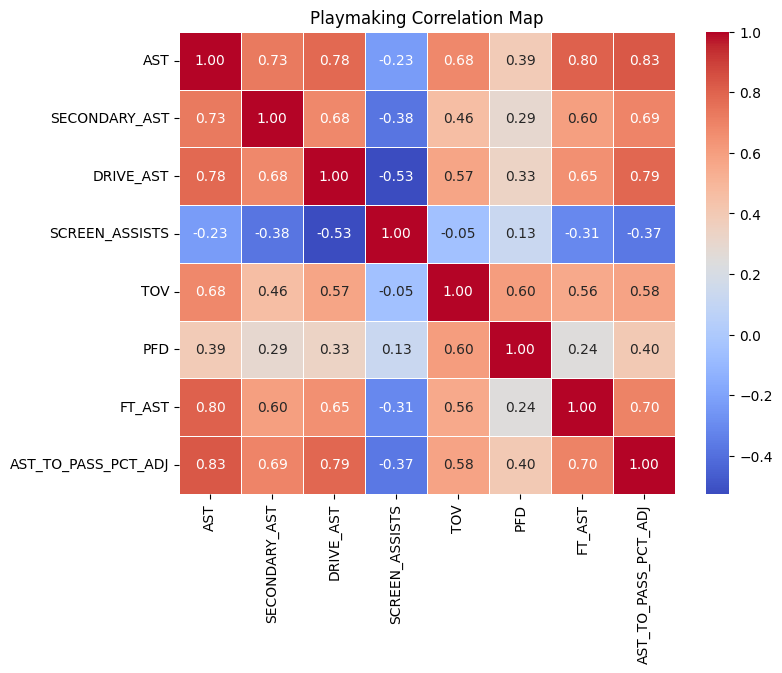

In [94]:
corr_matrix = X.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Playmaking Correlation Map")
plt.show()

In [95]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
#raw_variance = np.var(X, axis=0)
#scaled_variance = np.var(X_scaled, axis=0)


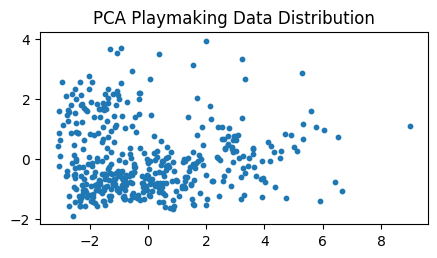

In [96]:
pca = PCA(n_components=2)
Z = pca.fit_transform(X_scaled)

plt.figure(figsize=(5,2.5))
plt.scatter(Z[:,0], Z[:,1], s=10)
plt.title("PCA Playmaking Data Distribution")
plt.show()

,k,silhouette,calinski_harabasz,davies_bouldin
0,2,0.396092,305.126950,1.043671
1,3,0.306902,245.543091,1.141326
2,4,0.269816,227.097160,1.213993
3,5,0.264877,198.516498,1.363292
4,6,0.233031,173.477104,1.522329
5,7,0.216512,157.700022,1.464553
6,8,0.216098,145.581697,1.514143
7,9,0.211495,134.865203,1.502204
8,10,0.189253,126.845329,1.540395


,covariance_type,k,bic,aic,silhouette,calinski_harabasz,davies_bouldin,avg_max_prob
9,diag,2,7839.692876,7705.896378,0.336401,276.559307,1.156703,0.977444
10,diag,3,7279.503403,7076.781436,0.230924,228.582265,1.365895,0.964740
11,diag,4,6978.308702,6706.661265,0.241672,214.663201,1.197762,0.964873
12,diag,5,6838.280151,6497.707246,0.238689,166.641014,1.451739,0.956219
13,diag,6,6749.740168,6340.241794,0.157922,140.945588,1.852648,0.944712
14,diag,7,6776.017854,6297.594011,0.165560,139.244206,1.786213,0.924396
15,diag,8,6747.428971,6200.079659,0.131080,123.047053,1.777217,0.920202
16,diag,9,6754.436847,6138.162066,0.124184,113.223625,1.954342,0.921406
17,diag,10,6803.543177,6118.342928,0.127837,104.623408,1.789760,0.914598
0,full,2,6769.030469,6408.185367,0.267054,206.448957,1.295486,0.940247


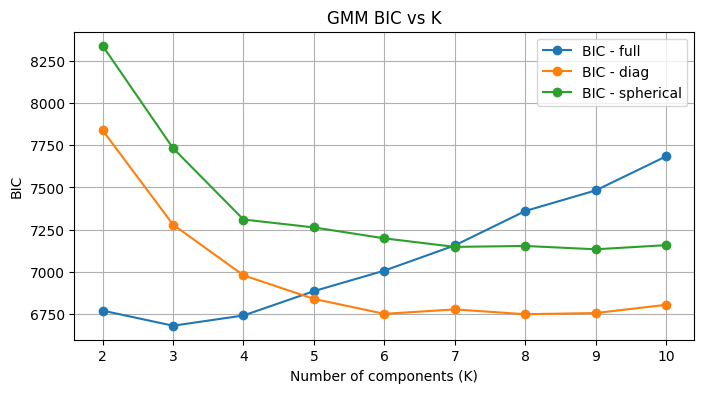

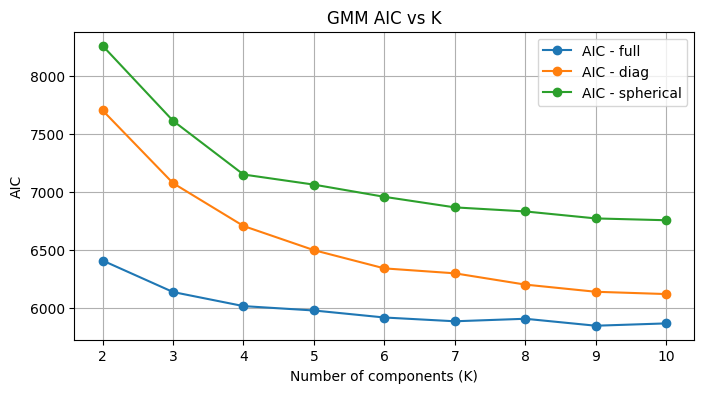

In [97]:
k_range = range(2, 11)
km_results = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)

    sil = silhouette_score(X_scaled, labels)
    ch = calinski_harabasz_score(X_scaled, labels)
    db = davies_bouldin_score(X_scaled, labels)

    km_results.append({
        "k": k,
        "silhouette": sil,
        "calinski_harabasz": ch,
        "davies_bouldin": db
    })
km_results_df = pd.DataFrame(km_results)
display(km_results_df)

k_range = range(2, 11)
cov_types = ["full", "diag","spherical"]

gmm_results = []

for cov in cov_types:
    for k in k_range:
        gmm = GaussianMixture(
            n_components=k,
            covariance_type=cov,
            n_init=10,
            reg_covar=1e-5,
            max_iter=500,
            init_params="kmeans",
            random_state=42)

        gmm.fit(X_scaled)
        labels = gmm.predict(X_scaled)
        probs = gmm.predict_proba(X_scaled)

        bic = gmm.bic(X_scaled)
        aic = gmm.aic(X_scaled)
        sil = silhouette_score(X_scaled, labels)
        ch = calinski_harabasz_score(X_scaled, labels)
        db = davies_bouldin_score(X_scaled, labels)
        avg_max_prob = probs.max(axis=1).mean()

        gmm_results.append({
            "covariance_type": cov,
            "k": k,
            "bic": bic,
            "aic": aic,
            "silhouette": sil,
            "calinski_harabasz": ch,
            "davies_bouldin": db,
            "avg_max_prob": avg_max_prob})

gmm_results_df = pd.DataFrame(gmm_results)
display(gmm_results_df.sort_values(["covariance_type", "k"]))

plt.figure(figsize=(8, 4))
for cov in cov_types:
    mask = gmm_results_df["covariance_type"] == cov
    sub = gmm_results_df[mask]
    plt.plot(sub["k"], sub["bic"], marker="o", label=f"BIC - {cov}")
plt.xlabel("Number of components (K)")
plt.ylabel("BIC")
plt.title("GMM BIC vs K")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
for cov in cov_types:
    mask = gmm_results_df["covariance_type"] == cov
    sub = gmm_results_df[mask]
    plt.plot(sub["k"], sub["aic"], marker="o", label=f"AIC - {cov}")
plt.xlabel("Number of components (K)")
plt.ylabel("AIC")
plt.title("GMM AIC vs K")
plt.legend()
plt.grid(True)
plt.show()


In [98]:
gmm_final = GaussianMixture(
    n_components=4,
    covariance_type='diag',
    n_init=10,
    reg_covar=1e-5,
    max_iter=500,
    init_params="kmeans",
    random_state=42
)

gmm_final.fit(X_scaled)

cluster_labels = gmm_final.predict(X_scaled)
cluster_probs = gmm_final.predict_proba(X_scaled)
passing["cluster"] = cluster_labels
passing[[f"cluster_prob_{k}" for k in range(4)]] = cluster_probs

In [99]:
cluster_means_scaled_features = pd.DataFrame(
    gmm_final.means_,
    columns=features # Label with original features since no PCA was applied before GMM
)
cluster_means_scaled_features.index.name = "cluster"

# GMM was fitted on scaled original features (X_scaled), so gmm_final.means_ are already in that space.
# We can directly use these means for the next step.
scaled_means_original_features = gmm_final.means_

cluster_means_std = pd.DataFrame(
    scaled_means_original_features,
    columns=features
)
cluster_means_std.index.name = "cluster"

# Inverse transform from scaled original feature space to original scale
cluster_means_original = pd.DataFrame(
    scaler.inverse_transform(scaled_means_original_features),
    columns=features
)
cluster_means_original.index.name = "cluster"

cluster_weights = pd.Series(gmm_final.weights_, index=cluster_means_std.index, name="weight")
cluster_counts = passing["cluster"].value_counts().sort_index()
cluster_avg_max_prob = pd.Series(
    cluster_probs.max(axis=1)
).groupby(passing["cluster"]).mean()
cluster_avg_max_prob.name = "avg_max_prob"

summary_overview = pd.concat(
    [cluster_weights, cluster_counts.rename("count"), cluster_avg_max_prob],
    axis=1
)

# Display the results
display(cluster_means_std)
display(cluster_means_original)
display(summary_overview)

,AST,SECONDARY_AST,DRIVE_AST,SCREEN_ASSISTS,TOV,PFD,FT_AST,AST_TO_PASS_PCT_ADJ
cluster,,,,,,,,
0,-0.863956,-0.585037,-0.626800,-0.390130,-0.861112,-0.650399,-0.642493,-0.757778
1,0.105574,0.174638,0.245177,-0.523869,-0.059479,-0.275749,0.156837,0.233126
2,1.492188,1.254596,1.412619,-0.460930,1.306183,1.004219,1.266622,1.376618
3,-0.516033,-0.724793,-0.924076,1.645230,-0.107962,0.237013,-0.642475,-0.719185


,AST,SECONDARY_AST,DRIVE_AST,SCREEN_ASSISTS,TOV,PFD,FT_AST,AST_TO_PASS_PCT_ADJ
cluster,,,,,,,,
0,2.071890,0.308817,0.286786,0.738087,1.269290,1.779589,0.158020,0.078853
1,3.932302,0.520888,0.744754,0.531717,1.900578,2.261826,0.347392,0.110914
2,6.593049,0.822369,1.357903,0.628836,2.976041,3.909356,0.610314,0.147912
3,2.739513,0.269803,0.130655,3.878834,1.862398,2.921835,0.158024,0.080101


,weight,count,avg_max_prob
cluster,,,
0,0.258507,109,0.951554
1,0.318716,137,0.956722
2,0.203094,85,0.985815
3,0.219683,95,0.973173


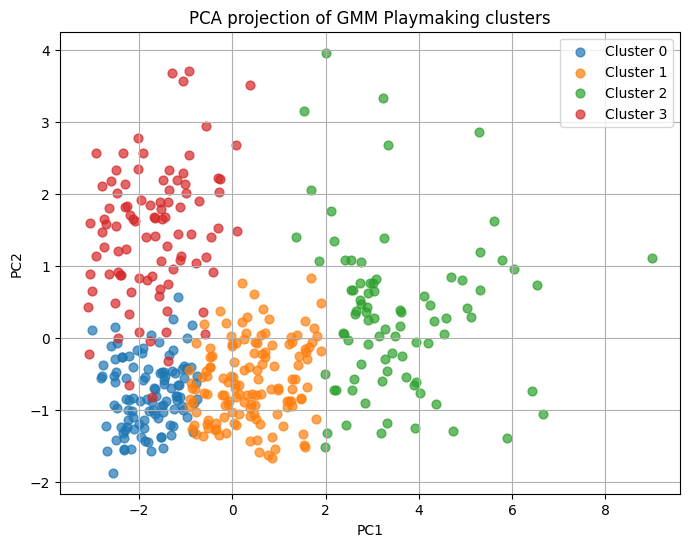

In [100]:
pca_vis = PCA(n_components=2)
X_pca_vis = pca_vis.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
palette = sns.color_palette("tab10", 4)

for k in range(4):
    mask = (cluster_labels == k)
    plt.scatter(
        X_pca_vis[mask, 0],
        X_pca_vis[mask, 1],
        s=40,
        alpha=0.7,
        color=palette[k],
        label=f"Cluster {k}"
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA projection of GMM Playmaking clusters")
plt.legend()
plt.grid(True)
plt.show()


In [101]:
def top_players_in_cluster(df, cluster_id, prob_matrix, top_n=10, player_col="PLAYER_NAME"):
    probs = prob_matrix[:, cluster_id]
    df_temp = df.copy()
    df_temp["cluster_prob"] = probs
    return (
        df_temp[df_temp["cluster"] == cluster_id]
        .sort_values("cluster_prob", ascending=False)
        [[player_col, "cluster", "cluster_prob"] + features]
        .head(top_n)
    )

for k in range(4):
    print(f"\n=== Cluster {k} ===")
    display(top_players_in_cluster(passing, k, cluster_probs))


=== Cluster 0 ===


,PLAYER_NAME,cluster,cluster_prob,AST,SECONDARY_AST,DRIVE_AST,SCREEN_ASSISTS,TOV,PFD,FT_AST,AST_TO_PASS_PCT_ADJ
245,Keegan Murray,0,0.999918,1.50,0.36,0.32,0.55,0.83,1.09,0.12,0.064
100,Dean Wade,0,0.999836,2.18,0.26,0.49,1.32,0.63,0.92,0.09,0.069
360,Ryan Dunn,0,0.999825,1.45,0.46,0.23,0.48,1.02,0.71,0.15,0.067
83,DaQuan Jeffries,0,0.999776,1.78,0.44,0.24,0.40,1.18,0.94,0.07,0.080
86,Dalton Knecht,0,0.999757,1.59,0.31,0.17,0.29,0.89,1.40,0.17,0.064
231,Julian Champagnie,0,0.999694,2.07,0.28,0.26,0.50,1.38,1.01,0.19,0.074
252,Kentavious Caldwell-Pope,0,0.999648,2.15,0.35,0.27,0.70,0.98,1.66,0.19,0.086
214,Johnny Juzang,0,0.999643,1.93,0.26,0.17,0.54,1.02,1.22,0.26,0.076
138,Gary Trent Jr.,0,0.999627,1.65,0.34,0.19,0.21,0.80,1.35,0.11,0.102
221,Jordan Hawkins,0,0.999623,1.80,0.27,0.44,0.33,1.58,1.99,0.16,0.069



=== Cluster 1 ===


,PLAYER_NAME,cluster,cluster_prob,AST,SECONDARY_AST,DRIVE_AST,SCREEN_ASSISTS,TOV,PFD,FT_AST,AST_TO_PASS_PCT_ADJ
365,Santi Aldama,1,0.999991,4.08,0.67,0.63,0.46,1.54,1.80,0.24,0.100
114,Dillon Jones,1,0.999990,3.79,0.39,0.78,0.85,1.83,1.37,0.39,0.101
386,Terry Rozier,1,0.999990,3.63,0.65,0.76,0.43,1.69,2.13,0.37,0.096
144,Grayson Allen,1,0.999988,3.19,0.51,0.91,0.49,1.75,2.47,0.33,0.100
4,Aaron Holiday,1,0.999986,3.77,0.45,0.77,0.23,1.68,2.23,0.27,0.110
2,AJ Johnson,1,0.999985,4.29,0.34,0.62,0.11,1.97,1.52,0.28,0.101
302,Miles McBride,1,0.999984,4.22,0.50,0.54,0.50,0.93,1.56,0.27,0.121
254,Keon Johnson,1,0.999983,3.27,0.41,0.92,0.37,2.17,2.24,0.22,0.096
334,Pat Connaughton,1,0.999983,4.18,0.48,1.07,0.60,1.43,1.85,0.30,0.100
93,David Roddy,1,0.999983,3.08,0.44,0.88,0.79,1.93,1.76,0.53,0.093



=== Cluster 2 ===


,PLAYER_NAME,cluster,cluster_prob,AST,SECONDARY_AST,DRIVE_AST,SCREEN_ASSISTS,TOV,PFD,FT_AST,AST_TO_PASS_PCT_ADJ
33,Ben Simmons,2,1.0,9.16,0.61,0.77,2.70,3.28,1.86,0.61,0.140
92,Darius Garland,2,1.0,7.92,1.35,2.39,0.27,2.96,3.55,0.89,0.206
54,Cade Cunningham,2,1.0,9.37,1.04,1.67,0.34,4.54,4.10,1.03,0.186
140,Giannis Antetokounmpo,2,1.0,6.81,0.69,0.93,2.30,3.24,7.98,0.41,0.140
128,Elfrid Payton,2,1.0,11.70,0.92,2.11,0.35,4.16,0.78,1.20,0.179
272,LaMelo Ball,2,1.0,8.28,1.17,1.68,0.45,4.00,5.29,0.79,0.165
281,Luka Dončić,2,1.0,7.80,0.92,1.93,0.20,3.64,5.96,0.55,0.179
318,Nikola Jokić,2,1.0,10.03,1.04,0.41,4.27,3.22,5.74,1.41,0.166
393,Trae Young,2,1.0,11.57,1.21,2.35,0.22,4.67,5.65,1.24,0.229
183,James Harden,2,1.0,8.87,0.89,1.77,0.05,4.40,4.79,0.81,0.186



=== Cluster 3 ===


,PLAYER_NAME,cluster,cluster_prob,AST,SECONDARY_AST,DRIVE_AST,SCREEN_ASSISTS,TOV,PFD,FT_AST,AST_TO_PASS_PCT_ADJ
7,Adem Bona,3,1.0,1.07,0.04,0.08,4.58,2.43,3.58,0.00,0.037
36,Bismack Biyombo,3,1.0,2.12,0.27,0.00,6.28,1.84,1.91,0.07,0.061
90,Daniel Theis,3,1.0,3.48,0.17,0.12,5.56,1.45,2.61,0.17,0.090
117,Donovan Clingan,3,1.0,2.09,0.11,0.00,4.98,1.96,2.67,0.14,0.068
101,Deandre Ayton,3,1.0,1.91,0.12,0.09,4.90,2.06,1.76,0.21,0.062
98,DeAndre Jordan,3,1.0,2.76,0.05,0.00,5.63,2.08,3.54,0.21,0.079
418,Yves Missi,3,1.0,1.82,0.20,0.07,4.66,1.51,3.06,0.04,0.065
312,Neemias Queta,3,1.0,1.88,0.17,0.08,5.38,1.67,2.42,0.17,0.090
314,Nick Richards,3,1.0,1.40,0.40,0.03,5.36,2.32,3.38,0.03,0.053
377,Steven Adams,3,1.0,2.99,0.27,0.14,6.44,2.45,4.67,0.18,0.085


In [102]:
role_labels_passing = {
    0: "Limited Playmaker",
    1: "Secondary Ball Handler",
    2: "Primary Playmaker",
    3: "Off-Ball Facilitator"}

passing["role_label"] = passing["cluster"].map(role_labels_passing)

In [103]:
means = passing.groupby("role_label")[['AST','SECONDARY_AST', 'DRIVE_AST', 'SCREEN_ASSISTS','TOV', 'PFD', 'FT_AST', 'AST_TO_PASS_PCT_ADJ']].mean()
means

,AST,SECONDARY_AST,DRIVE_AST,SCREEN_ASSISTS,TOV,PFD,FT_AST,AST_TO_PASS_PCT_ADJ
role_label,,,,,,,,
Limited Playmaker,2.051376,0.309633,0.286330,0.712294,1.266697,1.774862,0.157890,0.078670
Off-Ball Facilitator,2.746000,0.269684,0.131368,3.856000,1.857474,2.907579,0.158316,0.080284
Primary Playmaker,6.638118,0.828588,1.368000,0.628235,2.988824,3.921765,0.614353,0.148259
Secondary Ball Handler,3.942701,0.520657,0.747737,0.536642,1.905255,2.275255,0.348102,0.111182


# **Rebounding Analysis**

In [104]:
features = ['OREB_CHANCE_PCT', 'DREB_CHANCE_PCT', 'OREB_CONTEST_PCT', 'DREB_CONTEST_PCT','AVG_REB_DIST','BOX_OUT_EFF', 'REB_PLUSMINUS']

X = rebound[features]

array([[<Axes: title={'center': 'OREB_CHANCE_PCT'}>,
        <Axes: title={'center': 'DREB_CHANCE_PCT'}>,
        <Axes: title={'center': 'OREB_CONTEST_PCT'}>,
        <Axes: title={'center': 'DREB_CONTEST_PCT'}>],
       [<Axes: title={'center': 'AVG_REB_DIST'}>,
        <Axes: title={'center': 'BOX_OUT_EFF'}>,
        <Axes: title={'center': 'REB_PLUSMINUS'}>, <Axes: >]],
      dtype=object)

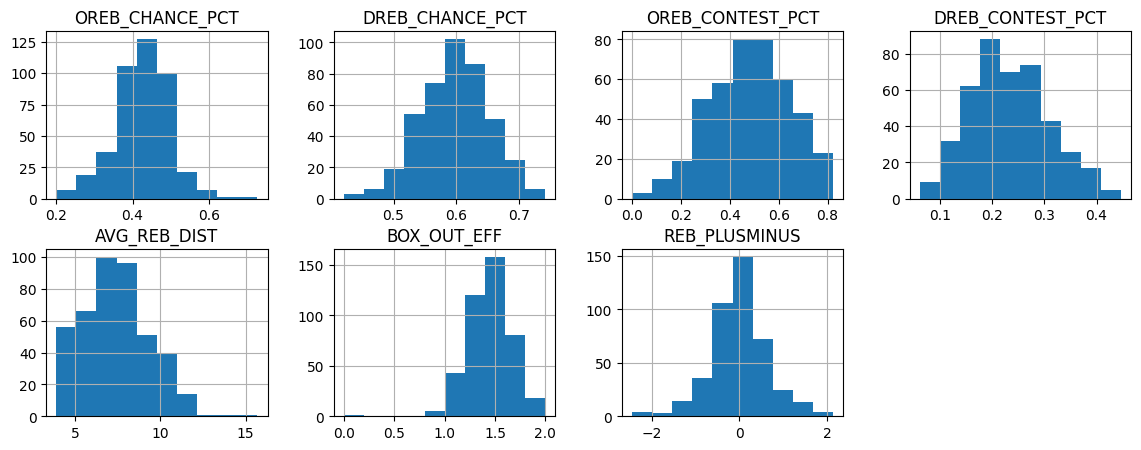

In [105]:
X.hist(figsize = (14,5),layout = (-1,4))

In [106]:
X.describe()

,OREB_CHANCE_PCT,DREB_CHANCE_PCT,OREB_CONTEST_PCT,DREB_CONTEST_PCT,AVG_REB_DIST,BOX_OUT_EFF,REB_PLUSMINUS
count,426.000000,426.000000,426.000000,426.000000,426.000000,426.000000,4.260000e+02
mean,0.426676,0.598336,0.478183,0.234009,7.469249,1.443048,4.169852e-16
std,0.070897,0.053926,0.162669,0.074196,1.931356,0.218221,6.388547e-01
min,0.200000,0.421000,0.000000,0.061000,3.900000,0.000000,-2.449839e+00
25%,0.383250,0.562000,0.368000,0.178250,6.000000,1.323529,-3.154591e-01
50%,0.430000,0.597500,0.480500,0.227000,7.350000,1.451297,-5.097774e-03
75%,0.473000,0.634000,0.600000,0.283000,8.700000,1.591047,3.250845e-01
max,0.727000,0.742000,0.823000,0.447000,15.700000,2.000000,2.137289e+00


In [107]:
X.var()

,0
OREB_CHANCE_PCT,0.005026
DREB_CHANCE_PCT,0.002908
OREB_CONTEST_PCT,0.026461
DREB_CONTEST_PCT,0.005505
AVG_REB_DIST,3.730134
BOX_OUT_EFF,0.047620
REB_PLUSMINUS,0.408135


In [108]:
X.skew()

,0
OREB_CHANCE_PCT,-0.137278
DREB_CHANCE_PCT,-0.132103
OREB_CONTEST_PCT,-0.228974
DREB_CONTEST_PCT,0.307101
AVG_REB_DIST,0.391749
BOX_OUT_EFF,-0.806392
REB_PLUSMINUS,-0.187980


In [109]:
X.kurt()

,0
OREB_CHANCE_PCT,0.871721
DREB_CHANCE_PCT,-0.088481
OREB_CONTEST_PCT,-0.319860
DREB_CONTEST_PCT,-0.368443
AVG_REB_DIST,0.078260
BOX_OUT_EFF,4.151259
REB_PLUSMINUS,1.674358


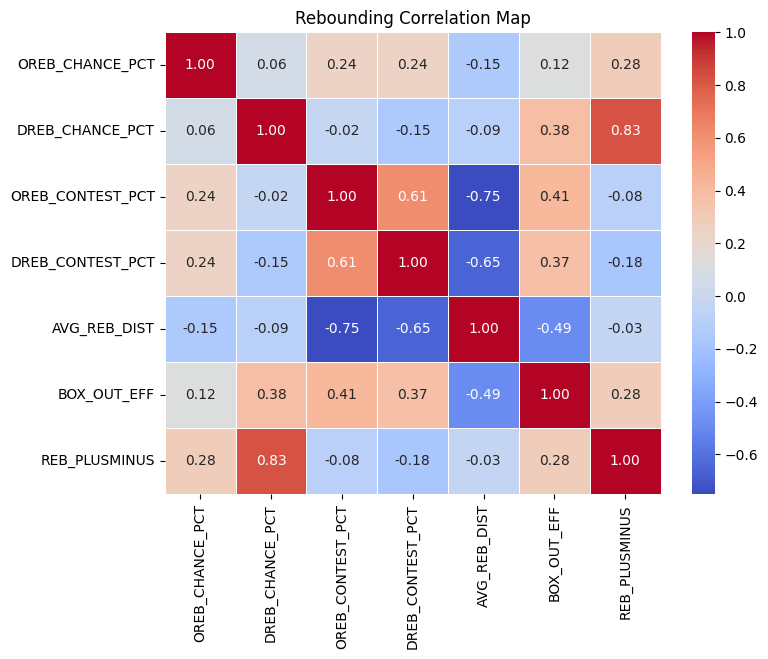

In [110]:
corr_matrix = X.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Rebounding Correlation Map")
plt.show()

In [111]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
#raw_variance = np.var(X, axis=0)
#scaled_variance = np.var(X_scaled, axis=0)

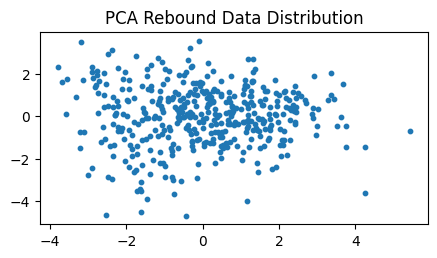

In [112]:
pca = PCA(n_components=2)
Z = pca.fit_transform(X_scaled)

plt.figure(figsize=(5,2.5))
plt.scatter(Z[:,0], Z[:,1], s=10)
plt.title("PCA Rebound Data Distribution")
plt.show()

,k,silhouette,calinski_harabasz,davies_bouldin
0,2,0.237209,153.086336,1.544384
1,3,0.228411,144.959656,1.339779
2,4,0.184523,124.022301,1.599518
3,5,0.184684,112.636804,1.492644
4,6,0.179721,105.447403,1.467993


,covariance_type,k,bic,aic,silhouette,calinski_harabasz,davies_bouldin,avg_max_prob
5,diag,2,7848.599076,7731.020335,0.234522,142.875023,1.552528,0.957617
6,diag,3,7732.248094,7553.852763,0.158313,104.246447,1.842387,0.922507
7,diag,4,7610.976156,7371.764235,0.160315,107.025490,1.613018,0.918301
8,diag,5,7513.044989,7213.016477,0.170870,106.729182,1.538306,0.901254
9,diag,6,7440.580242,7079.735140,0.152341,94.217719,1.682160,0.907623
0,full,2,6746.877564,6459.012370,0.208002,123.478245,1.664951,0.938820
1,full,3,6864.292653,6430.467643,0.170006,105.305098,1.468578,0.894128
2,full,4,6885.929564,6306.144738,0.060342,60.666045,2.616654,0.872708
3,full,5,7056.116866,6330.372223,0.083830,64.188366,2.100485,0.861019
4,full,6,7138.339962,6266.635502,0.087800,55.525759,1.953596,0.860055


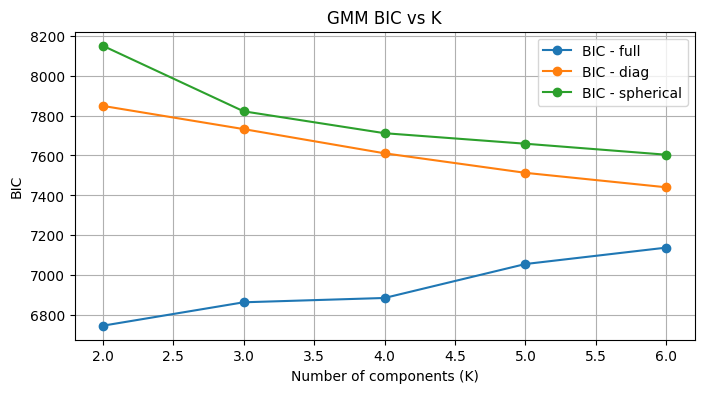

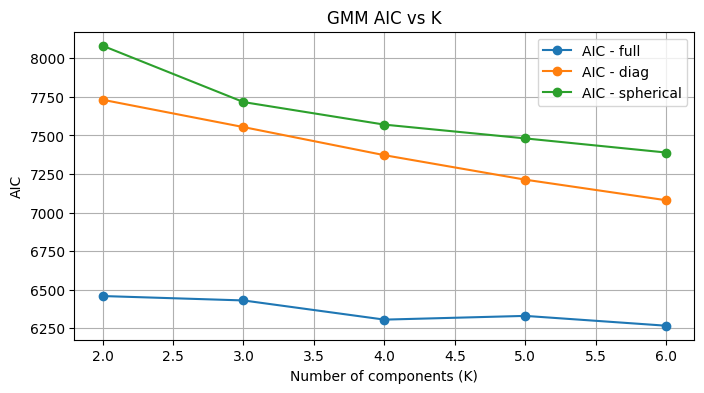

In [113]:
k_range = range(2, 7)
km_results = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)

    sil = silhouette_score(X_scaled, labels)
    ch = calinski_harabasz_score(X_scaled, labels)
    db = davies_bouldin_score(X_scaled, labels)

    km_results.append({
        "k": k,
        "silhouette": sil,
        "calinski_harabasz": ch,
        "davies_bouldin": db
    })
km_results_df = pd.DataFrame(km_results)
display(km_results_df)

k_range = range(2, 7)
cov_types = ["full", "diag","spherical"]

gmm_results = []

for cov in cov_types:
    for k in k_range:
        gmm = GaussianMixture(
            n_components=k,
            covariance_type=cov,
            n_init=10,
            reg_covar=1e-5,
            max_iter=500,
            init_params="kmeans",
            random_state=42)

        gmm.fit(X_scaled)
        labels = gmm.predict(X_scaled)
        probs = gmm.predict_proba(X_scaled)

        bic = gmm.bic(X_scaled)
        aic = gmm.aic(X_scaled)
        sil = silhouette_score(X_scaled, labels)
        ch = calinski_harabasz_score(X_scaled, labels)
        db = davies_bouldin_score(X_scaled, labels)
        avg_max_prob = probs.max(axis=1).mean()

        gmm_results.append({
            "covariance_type": cov,
            "k": k,
            "bic": bic,
            "aic": aic,
            "silhouette": sil,
            "calinski_harabasz": ch,
            "davies_bouldin": db,
            "avg_max_prob": avg_max_prob})

gmm_results_df = pd.DataFrame(gmm_results)
display(gmm_results_df.sort_values(["covariance_type", "k"]))

plt.figure(figsize=(8, 4))
for cov in cov_types:
    mask = gmm_results_df["covariance_type"] == cov
    sub = gmm_results_df[mask]
    plt.plot(sub["k"], sub["bic"], marker="o", label=f"BIC - {cov}")
plt.xlabel("Number of components (K)")
plt.ylabel("BIC")
plt.title("GMM BIC vs K")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
for cov in cov_types:
    mask = gmm_results_df["covariance_type"] == cov
    sub = gmm_results_df[mask]
    plt.plot(sub["k"], sub["aic"], marker="o", label=f"AIC - {cov}")
plt.xlabel("Number of components (K)")
plt.ylabel("AIC")
plt.title("GMM AIC vs K")
plt.legend()
plt.grid(True)
plt.show()


In [114]:
gmm_final = GaussianMixture(
    n_components=4,
    covariance_type='full',
    n_init=10,
    reg_covar=1e-5,
    max_iter=500,
    init_params="kmeans",
    random_state=42
)

gmm_final.fit(X_scaled)

cluster_labels = gmm_final.predict(X_scaled)
cluster_probs = gmm_final.predict_proba(X_scaled)
rebound["cluster"] = cluster_labels
rebound[[f"cluster_prob_{k}" for k in range(4)]] = cluster_probs

In [115]:
cluster_means_scaled_features = pd.DataFrame(
    gmm_final.means_,
    columns=features
)
cluster_means_scaled_features.index.name = "cluster"

scaled_means_original_features = gmm_final.means_

cluster_means_std = pd.DataFrame(
    scaled_means_original_features,
    columns=features
)
cluster_means_std.index.name = "cluster"

cluster_means_original = pd.DataFrame(
    scaler.inverse_transform(scaled_means_original_features),
    columns=features
)
cluster_means_original.index.name = "cluster"

cluster_weights = pd.Series(gmm_final.weights_, index=cluster_means_std.index, name="weight")
cluster_counts = rebound["cluster"].value_counts().sort_index()
cluster_avg_max_prob = pd.Series(
    cluster_probs.max(axis=1)
).groupby(rebound["cluster"]).mean()
cluster_avg_max_prob.name = "avg_max_prob"

summary_overview = pd.concat(
    [cluster_weights, cluster_counts.rename("count"), cluster_avg_max_prob],
    axis=1
)

display(cluster_means_std)
display(cluster_means_original)
display(summary_overview)

,OREB_CHANCE_PCT,DREB_CHANCE_PCT,OREB_CONTEST_PCT,DREB_CONTEST_PCT,AVG_REB_DIST,BOX_OUT_EFF,REB_PLUSMINUS
cluster,,,,,,,
0,0.282898,-0.038348,1.176247,1.278993,-1.318556,0.632808,-0.169932
1,-0.029784,0.236089,0.263508,0.033893,-0.433433,0.266397,0.193673
2,-0.049571,-0.209057,-0.212672,-0.329498,0.430659,-0.190130,-0.113152
3,-0.174273,0.195142,-1.279454,-0.785441,1.180228,-0.691782,0.185787


,OREB_CHANCE_PCT,DREB_CHANCE_PCT,OREB_CONTEST_PCT,DREB_CONTEST_PCT,AVG_REB_DIST,BOX_OUT_EFF,REB_PLUSMINUS
cluster,,,,,,,
0,0.446709,0.596270,0.669297,0.328794,4.925639,1.580978,-0.108434
1,0.424567,0.611052,0.520997,0.236521,6.633118,1.501113,0.123583
2,0.423166,0.587075,0.443629,0.209591,8.300027,1.401607,-0.072203
3,0.414335,0.608846,0.270300,0.175801,9.746013,1.292264,0.118552


,weight,count,avg_max_prob
cluster,,,
0,0.196691,86,0.948463
1,0.243859,102,0.867035
2,0.393870,170,0.848766
3,0.165579,68,0.845268


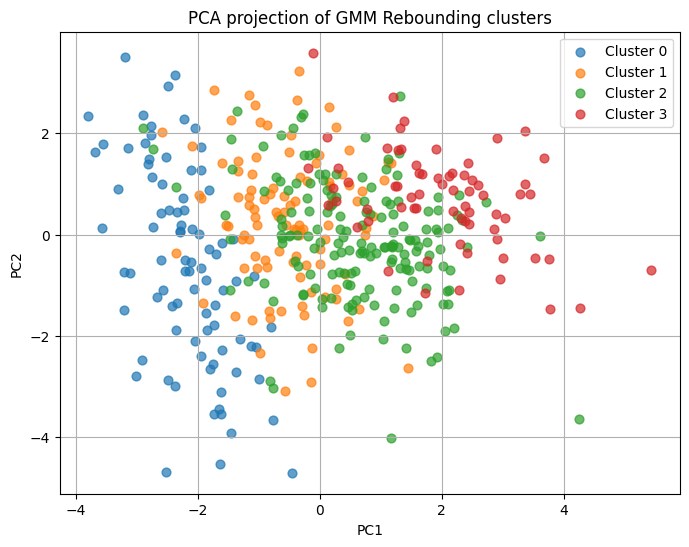

In [116]:
pca_vis = PCA(n_components=2)
X_pca_vis = pca_vis.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
palette = sns.color_palette("tab10", 4)

for k in range(4):
    mask = (cluster_labels == k)
    plt.scatter(
        X_pca_vis[mask, 0],
        X_pca_vis[mask, 1],
        s=40,
        alpha=0.7,
        color=palette[k],
        label=f"Cluster {k}"
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA projection of GMM Rebounding clusters")
plt.legend()
plt.grid(True)
plt.show()


In [117]:
def top_players_in_cluster(df, cluster_id, prob_matrix, top_n=10, player_col="PLAYER_NAME"):
    probs = prob_matrix[:, cluster_id]
    df_temp = df.copy()
    df_temp["cluster_prob"] = probs
    return (
        df_temp[df_temp["cluster"] == cluster_id]
        .sort_values("cluster_prob", ascending=False)
        [[player_col, "cluster", "cluster_prob"] + features]
        .head(top_n)
    )

for k in range(4):
    print(f"\n=== Cluster {k} ===")
    display(top_players_in_cluster(rebound, k, cluster_probs))


=== Cluster 0 ===


,PLAYER_NAME,cluster,cluster_prob,OREB_CHANCE_PCT,DREB_CHANCE_PCT,OREB_CONTEST_PCT,DREB_CONTEST_PCT,AVG_REB_DIST,BOX_OUT_EFF,REB_PLUSMINUS
308,Moussa Diabaté,0,1.0,0.385,0.589,0.695,0.303,4.7,1.642173,-2.002069
328,Orlando Robinson,0,1.0,0.360,0.533,0.708,0.336,5.1,1.525581,-2.330596
209,Jock Landale,0,1.0,0.381,0.591,0.589,0.383,5.6,1.538889,-1.442110
7,Adem Bona,0,1.0,0.380,0.489,0.815,0.294,4.5,1.527094,-2.449839
98,DeAndre Jordan,0,1.0,0.491,0.714,0.768,0.249,4.7,1.780556,2.137289
412,Victor Wembanyama,0,1.0,0.488,0.647,0.683,0.325,4.9,1.661972,1.532001
89,Daniel Gafford,0,1.0,0.427,0.474,0.768,0.395,4.1,1.609848,-2.274038
95,Day'Ron Sharpe,0,1.0,0.434,0.539,0.765,0.326,3.9,1.640227,-1.536260
351,Richaun Holmes,0,1.0,0.422,0.556,0.806,0.374,4.4,1.420513,-1.427158
17,Andre Drummond,0,1.0,0.514,0.672,0.688,0.373,4.5,1.836431,1.741004



=== Cluster 1 ===


,PLAYER_NAME,cluster,cluster_prob,OREB_CHANCE_PCT,DREB_CHANCE_PCT,OREB_CONTEST_PCT,DREB_CONTEST_PCT,AVG_REB_DIST,BOX_OUT_EFF,REB_PLUSMINUS
220,Jordan Goodwin,1,1.000000,0.376,0.514,0.711,0.243,7.1,1.353982,-1.402882
365,Santi Aldama,1,1.000000,0.457,0.696,0.473,0.125,6.7,1.589744,1.499206
256,Kevin Durant,1,0.999999,0.284,0.702,0.261,0.274,7.4,1.550000,0.942477
199,Jayson Tatum,1,0.999998,0.324,0.708,0.333,0.189,6.0,1.491525,1.095970
326,Olivier-Maxence Prosper,1,0.999994,0.396,0.558,0.614,0.207,7.4,1.231250,-0.895781
384,Terance Mann,1,0.999965,0.384,0.562,0.544,0.198,6.7,1.475410,-0.755960
226,Josh Giddey,1,0.999961,0.496,0.654,0.496,0.191,6.3,1.625000,1.157757
276,LeBron James,1,0.999960,0.369,0.695,0.542,0.224,6.7,1.615385,1.000111
40,Bol Bol,1,0.999919,0.541,0.683,0.450,0.214,6.4,1.615385,1.307843
146,Gui Santos,1,0.999796,0.477,0.505,0.431,0.300,7.0,1.413043,-0.970482



=== Cluster 2 ===


,PLAYER_NAME,cluster,cluster_prob,OREB_CHANCE_PCT,DREB_CHANCE_PCT,OREB_CONTEST_PCT,DREB_CONTEST_PCT,AVG_REB_DIST,BOX_OUT_EFF,REB_PLUSMINUS
396,Tre Mann,2,1.000000,0.387,0.473,0.417,0.154,8.3,0.000000,-1.030813
173,Jalen Hood-Schifino,2,1.000000,0.600,0.533,0.000,0.250,7.2,1.323529,-0.083624
413,Vince Williams Jr.,2,0.999995,0.423,0.742,0.409,0.116,7.4,1.000000,0.960676
85,Dalen Terry,2,0.999988,0.452,0.494,0.421,0.221,7.6,1.000000,-0.707696
187,Jared McCain,2,0.999979,0.342,0.483,0.308,0.256,8.2,1.139535,-0.806703
2,AJ Johnson,2,0.999967,0.267,0.443,0.750,0.216,7.5,1.000000,-1.208504
222,Jordan Miller,2,0.999966,0.460,0.515,0.652,0.257,7.4,1.000000,-0.589390
366,Scoot Henderson,2,0.999934,0.342,0.500,0.346,0.178,9.3,1.363636,-0.910174
152,Isaac Okoro,2,0.999933,0.430,0.529,0.490,0.346,10.2,1.330097,-0.772471
91,Dante Exum,2,0.999918,0.200,0.644,0.500,0.241,9.8,2.000000,-0.299876



=== Cluster 3 ===


,PLAYER_NAME,cluster,cluster_prob,OREB_CHANCE_PCT,DREB_CHANCE_PCT,OREB_CONTEST_PCT,DREB_CONTEST_PCT,AVG_REB_DIST,BOX_OUT_EFF,REB_PLUSMINUS
336,Patty Mills,3,1.000000,0.333,0.545,0.000,0.222,15.7,0.835821,-0.270857
288,Marcus Sasser,3,0.999999,0.474,0.680,0.167,0.157,13.8,1.148148,0.352433
348,Reece Beekman,3,0.999999,0.565,0.650,0.308,0.346,11.2,1.326087,0.310174
353,Rob Dillingham,3,0.999978,0.545,0.704,0.167,0.184,10.1,1.500000,0.549405
134,Gabe Vincent,3,0.999960,0.400,0.483,0.100,0.181,12.7,0.969697,-0.421053
350,Reggie Jackson,3,0.999952,0.727,0.630,0.250,0.235,9.6,1.473684,0.611024
129,Eric Gordon,3,0.999949,0.276,0.514,0.250,0.158,11.1,1.000000,-0.446601
372,Shake Milton,3,0.999614,0.463,0.682,0.387,0.342,9.9,1.500000,0.346522
422,Zach LaVine,3,0.999188,0.224,0.631,0.136,0.133,7.9,1.666667,0.137749
207,Jevon Carter,3,0.997596,0.286,0.636,0.000,0.086,10.1,1.323529,0.268715


In [118]:
role_labels_reb = {
    0: "Interior Physical Sweeper",
    1: "Two-way Effective Rebounder",
    2: "Reliable Positional Rebounder",
    3: "Long Range Circumstantial Rebounder"
}

rebound["role_label"] = rebound["cluster"].map(role_labels_reb)

In [119]:
means = rebound.groupby("role_label")[['OREB_CHANCE_PCT', 'DREB_CHANCE_PCT', 'OREB_CONTEST_PCT', 'DREB_CONTEST_PCT','AVG_REB_DIST','BOX_OUT_EFF', 'REB_PLUSMINUS']].mean()
means

,OREB_CHANCE_PCT,DREB_CHANCE_PCT,OREB_CONTEST_PCT,DREB_CONTEST_PCT,AVG_REB_DIST,BOX_OUT_EFF,REB_PLUSMINUS
role_label,,,,,,,
Interior Physical Sweeper,0.447140,0.596663,0.667047,0.328756,4.925581,1.580430,-0.098677
Long Range Circumstantial Rebounder,0.416368,0.611191,0.252603,0.173691,9.897059,1.289641,0.140393
Reliable Positional Rebounder,0.422206,0.585206,0.446035,0.210341,8.294706,1.400973,-0.089814
Two-way Effective Rebounder,0.423745,0.613059,0.522912,0.233784,6.619608,1.499613,0.139293


# **Defense Analysis**

In [120]:
features = ['STL','BLK','D_FG_PCT','DEF_RIM_FG_PCT','DIST_MILES_DEF','PF','DEFLECTIONS', 'LOOSE_BALLS_RECOVERED']

X = defense[features]

array([[<Axes: title={'center': 'STL'}>, <Axes: title={'center': 'BLK'}>,
        <Axes: title={'center': 'D_FG_PCT'}>,
        <Axes: title={'center': 'DEF_RIM_FG_PCT'}>],
       [<Axes: title={'center': 'DIST_MILES_DEF'}>,
        <Axes: title={'center': 'PF'}>,
        <Axes: title={'center': 'DEFLECTIONS'}>,
        <Axes: title={'center': 'LOOSE_BALLS_RECOVERED'}>]], dtype=object)

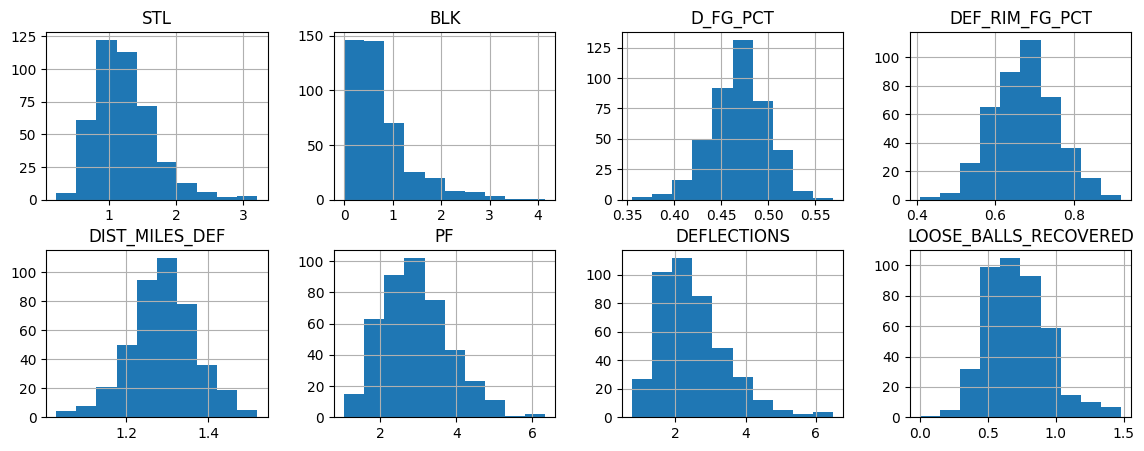

In [121]:
X.hist(figsize = (14,5),layout = (-1,4))

In [122]:
X.describe()

,STL,BLK,D_FG_PCT,DEF_RIM_FG_PCT,DIST_MILES_DEF,PF,DEFLECTIONS,LOOSE_BALLS_RECOVERED
count,426.000000,426.000000,426.000000,426.000000,426.000000,426.000000,426.000000,426.000000
mean,1.236620,0.766784,0.468852,0.672411,1.289953,2.924155,2.502113,0.715798
std,0.449206,0.623368,0.030257,0.080157,0.082880,0.877044,0.967933,0.224789
min,0.220000,0.000000,0.355000,0.408000,1.030000,1.040000,0.760000,0.000000
25%,0.920000,0.340000,0.449000,0.617000,1.240000,2.252500,1.820000,0.560000
50%,1.160000,0.575000,0.470000,0.675500,1.290000,2.800000,2.340000,0.695000
75%,1.460000,1.010000,0.489000,0.726000,1.340000,3.507500,2.997500,0.850000
max,3.210000,4.150000,0.569000,0.919000,1.520000,6.340000,6.500000,1.480000


In [123]:
X.var()

,0
STL,0.201786
BLK,0.388588
D_FG_PCT,0.000916
DEF_RIM_FG_PCT,0.006425
DIST_MILES_DEF,0.006869
PF,0.769206
DEFLECTIONS,0.936893
LOOSE_BALLS_RECOVERED,0.050530


In [124]:
X.kurt()

,0
STL,2.223470
BLK,4.048377
D_FG_PCT,0.454352
DEF_RIM_FG_PCT,0.057748
DIST_MILES_DEF,0.190091
PF,0.297331
DEFLECTIONS,1.944320
LOOSE_BALLS_RECOVERED,0.694471


In [125]:
X.skew()

,0
STL,1.131476
BLK,1.821275
D_FG_PCT,-0.212959
DEF_RIM_FG_PCT,-0.000237
DIST_MILES_DEF,-0.073443
PF,0.586127
DEFLECTIONS,1.124825
LOOSE_BALLS_RECOVERED,0.573393


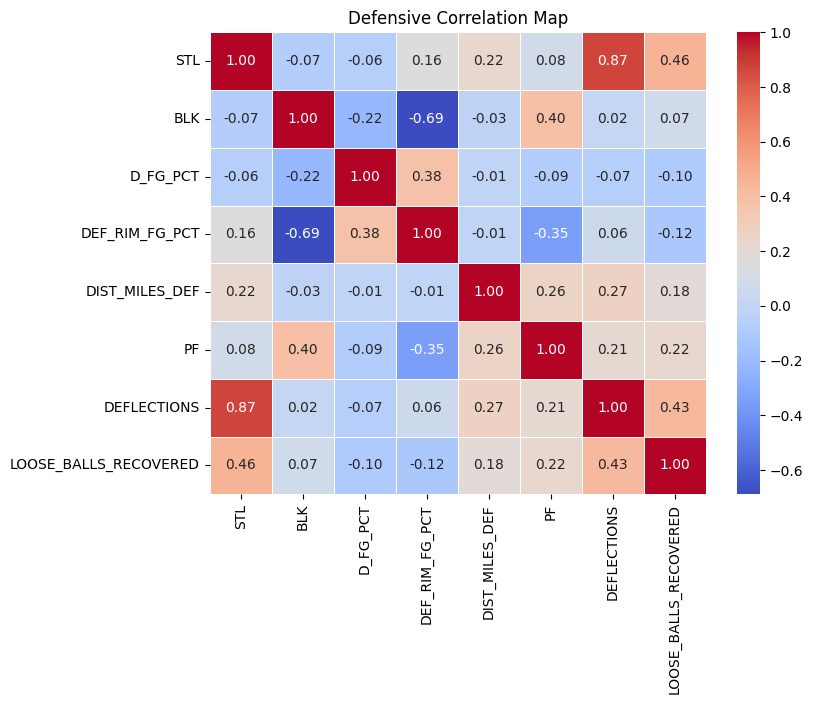

In [126]:
corr_matrix = X.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Defensive Correlation Map")
plt.show()

In [127]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
#raw_variance = np.var(X, axis=0)
#scaled_variance = np.var(X_scaled, axis=0)


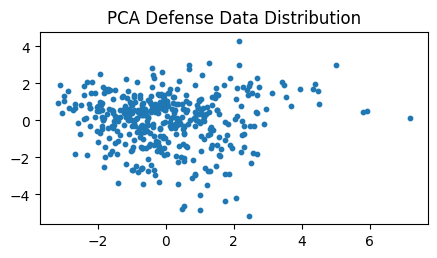

In [128]:
pca = PCA(n_components=2)
Z = pca.fit_transform(X_scaled)

plt.figure(figsize=(5,2.5))
plt.scatter(Z[:,0], Z[:,1], s=10)
plt.title("PCA Defense Data Distribution")
plt.show()

,k,silhouette,calinski_harabasz,davies_bouldin
0,2,0.209055,101.431060,1.904073
1,3,0.215501,106.871762,1.528179
2,4,0.149735,91.434258,1.779106
3,5,0.133510,81.285055,1.792191
4,6,0.131236,73.597806,1.651200
5,7,0.136954,68.960569,1.711867
6,8,0.135568,64.775714,1.663574


,covariance_type,k,bic,aic,silhouette,calinski_harabasz,davies_bouldin,avg_max_prob
7,diag,2,9236.691372,9102.894874,0.174715,79.378046,2.195944,0.939651
8,diag,3,8916.559926,8713.837959,0.198142,100.685959,1.609574,0.937064
9,diag,4,8827.862001,8556.214565,0.116722,81.669277,1.923053,0.920566
10,diag,5,8823.636343,8483.063438,0.082188,68.257920,2.097903,0.910944
11,diag,6,8826.013933,8416.515559,0.082846,61.356253,2.058407,0.886749
12,diag,7,8821.406694,8342.982851,0.090141,58.672230,2.080406,0.888330
13,diag,8,8863.497123,8316.147811,0.077278,51.033831,2.029560,0.897062
0,full,2,8530.038596,8169.193495,0.198101,81.824596,1.867469,0.958275
1,full,3,8639.427466,8096.132593,0.161373,78.677761,1.935601,0.897927
2,full,4,8810.796393,8085.051750,0.103641,67.200904,2.101076,0.900639


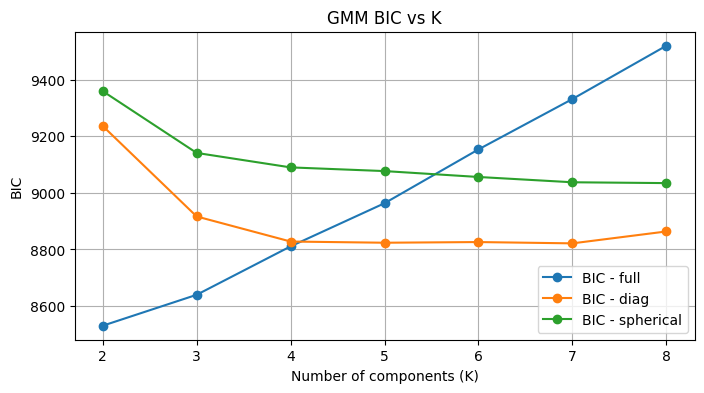

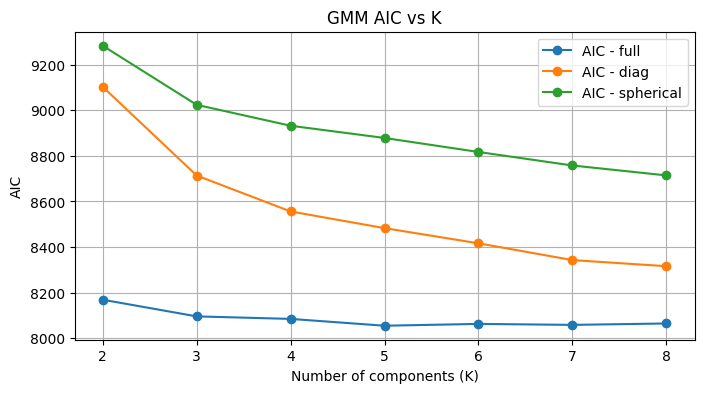

In [129]:
k_range = range(2, 9)
km_results = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)

    sil = silhouette_score(X_scaled, labels)
    ch = calinski_harabasz_score(X_scaled, labels)
    db = davies_bouldin_score(X_scaled, labels)

    km_results.append({
        "k": k,
        "silhouette": sil,
        "calinski_harabasz": ch,
        "davies_bouldin": db
    })
km_results_df = pd.DataFrame(km_results)
display(km_results_df)

k_range = range(2, 9)
cov_types = ["full", "diag","spherical"]

gmm_results = []

for cov in cov_types:
    for k in k_range:
        gmm = GaussianMixture(
            n_components=k,
            covariance_type=cov,
            n_init=10,
            reg_covar=1e-5,
            max_iter=500,
            init_params="kmeans",
            random_state=42)

        gmm.fit(X_scaled)
        labels = gmm.predict(X_scaled)
        probs = gmm.predict_proba(X_scaled)

        bic = gmm.bic(X_scaled)
        aic = gmm.aic(X_scaled)
        sil = silhouette_score(X_scaled, labels)
        ch = calinski_harabasz_score(X_scaled, labels)
        db = davies_bouldin_score(X_scaled, labels)
        avg_max_prob = probs.max(axis=1).mean()

        gmm_results.append({
            "covariance_type": cov,
            "k": k,
            "bic": bic,
            "aic": aic,
            "silhouette": sil,
            "calinski_harabasz": ch,
            "davies_bouldin": db,
            "avg_max_prob": avg_max_prob})

gmm_results_df = pd.DataFrame(gmm_results)
display(gmm_results_df.sort_values(["covariance_type", "k"]))

plt.figure(figsize=(8, 4))
for cov in cov_types:
    mask = gmm_results_df["covariance_type"] == cov
    sub = gmm_results_df[mask]
    plt.plot(sub["k"], sub["bic"], marker="o", label=f"BIC - {cov}")
plt.xlabel("Number of components (K)")
plt.ylabel("BIC")
plt.title("GMM BIC vs K")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
for cov in cov_types:
    mask = gmm_results_df["covariance_type"] == cov
    sub = gmm_results_df[mask]
    plt.plot(sub["k"], sub["aic"], marker="o", label=f"AIC - {cov}")
plt.xlabel("Number of components (K)")
plt.ylabel("AIC")
plt.title("GMM AIC vs K")
plt.legend()
plt.grid(True)
plt.show()


In [130]:
gmm_final = GaussianMixture(
    n_components=5,
    covariance_type='diag',
    n_init=10,
    reg_covar=1e-5,
    max_iter=500,
    init_params="kmeans",
    random_state=42
)

gmm_final.fit(X_scaled)

cluster_labels = gmm_final.predict(X_scaled)
cluster_probs = gmm_final.predict_proba(X_scaled)
defense["cluster"] = cluster_labels
defense[[f"cluster_prob_{k}" for k in range(5)]] = cluster_probs

In [131]:
cluster_means_scaled_features = pd.DataFrame(
    gmm_final.means_,
    columns=features
)
cluster_means_scaled_features.index.name = "cluster"
scaled_means_original_features = gmm_final.means_

cluster_means_std = pd.DataFrame(
    scaled_means_original_features,
    columns=features
)
cluster_means_std.index.name = "cluster"

cluster_means_original = pd.DataFrame(
    scaler.inverse_transform(scaled_means_original_features),
    columns=features
)
cluster_means_original.index.name = "cluster"

cluster_weights = pd.Series(gmm_final.weights_, index=cluster_means_std.index, name="weight")
cluster_counts = defense["cluster"].value_counts().sort_index()
cluster_avg_max_prob = pd.Series(
    cluster_probs.max(axis=1)
).groupby(defense["cluster"]).mean()
cluster_avg_max_prob.name = "avg_max_prob"

summary_overview = pd.concat(
    [cluster_weights, cluster_counts.rename("count"), cluster_avg_max_prob],
    axis=1
)


display(cluster_means_std)
display(cluster_means_original)
display(summary_overview)

,STL,BLK,D_FG_PCT,DEF_RIM_FG_PCT,DIST_MILES_DEF,PF,DEFLECTIONS,LOOSE_BALLS_RECOVERED
cluster,,,,,,,,
0,-0.581471,-0.463851,0.039650,0.143286,-0.016446,-0.350190,-0.643973,-0.272092
1,1.770382,-0.060878,-0.079184,0.209005,0.726707,0.407690,1.809215,1.154566
2,-0.764741,-0.908144,0.669726,1.293409,-0.588714,-0.889272,-0.934973,-0.768094
3,-0.532245,1.256943,-0.247039,-1.154450,-0.175214,0.649591,-0.386945,-0.066224
4,0.389336,-0.416294,0.015715,0.403928,0.029696,-0.189874,0.348080,0.009480


,STL,BLK,D_FG_PCT,DEF_RIM_FG_PCT,DIST_MILES_DEF,PF,DEFLECTIONS,LOOSE_BALLS_RECOVERED
cluster,,,,,,,,
0,0.975727,0.477974,0.470050,0.683883,1.288592,2.617384,1.879522,0.654707
1,2.030951,0.728879,0.466459,0.689144,1.350112,3.281297,4.251254,0.975028
2,0.893497,0.201341,0.489092,0.775965,1.241217,2.145140,1.598184,0.543341
3,0.997813,1.549402,0.461386,0.579982,1.275448,3.493205,2.128016,0.700929
4,1.411306,0.507585,0.469327,0.704751,1.292411,2.757822,2.838634,0.717927


,weight,count,avg_max_prob
cluster,,,
0,0.233692,100,0.884232
1,0.125734,53,0.925288
2,0.087944,36,0.926294
3,0.254581,110,0.941371
4,0.298049,127,0.895288


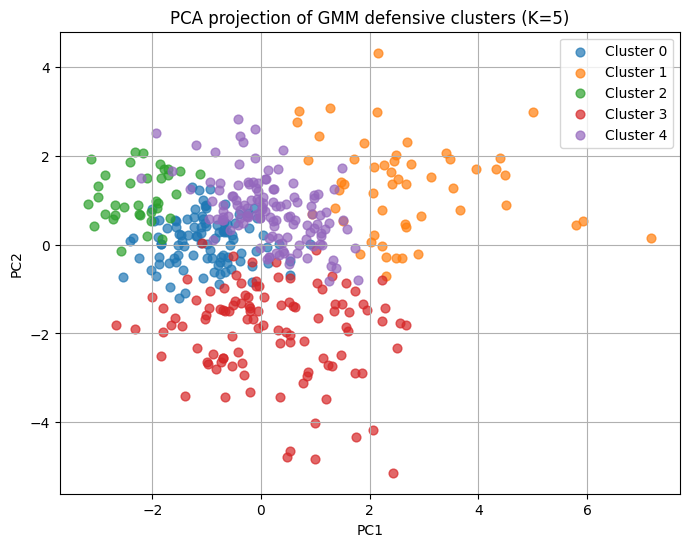

In [132]:
pca_vis = PCA(n_components=2)
X_pca_vis = pca_vis.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
palette = sns.color_palette("tab10", 5)

for k in range(5):
    mask = (cluster_labels == k)
    plt.scatter(
        X_pca_vis[mask, 0],
        X_pca_vis[mask, 1],
        s=40,
        alpha=0.7,
        color=palette[k],
        label=f"Cluster {k}"
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA projection of GMM defensive clusters (K=5)")
plt.legend()
plt.grid(True)
plt.show()


In [133]:
def top_players_in_cluster(df, cluster_id, prob_matrix, top_n=10, player_col="PLAYER_NAME"):
    probs = prob_matrix[:, cluster_id]
    df_temp = df.copy()
    df_temp["cluster_prob"] = probs
    return (
        df_temp[df_temp["cluster"] == cluster_id]
        .sort_values("cluster_prob", ascending=False)
        [[player_col, "cluster", "cluster_prob"] + features]
        .head(top_n)
    )

for k in range(5):
    print(f"\n=== Cluster {k} ===")
    display(top_players_in_cluster(defense, k, cluster_probs))


=== Cluster 0 ===


,PLAYER_NAME,cluster,cluster_prob,STL,BLK,D_FG_PCT,DEF_RIM_FG_PCT,DIST_MILES_DEF,PF,DEFLECTIONS,LOOSE_BALLS_RECOVERED
221,Jordan Hawkins,0,0.999316,0.82,0.63,0.477,0.728,1.37,1.39,1.53,0.52
73,Cody Williams,0,0.998358,0.78,0.54,0.483,0.746,1.40,3.23,1.73,0.41
332,Paolo Banchero,0,0.997898,0.82,0.64,0.446,0.688,1.16,2.21,1.34,0.57
294,Max Strus,0,0.997871,0.74,0.34,0.492,0.703,1.40,2.94,1.30,0.96
45,Brandon Ingram,0,0.997227,0.97,0.67,0.525,0.698,1.13,2.72,1.15,0.54
34,Bennedict Mathurin,0,0.996625,0.79,0.40,0.500,0.685,1.34,2.71,1.52,0.80
358,Rui Hachimura,0,0.996134,0.87,0.50,0.456,0.686,1.29,2.02,1.89,0.50
206,Jett Howard,0,0.993994,0.67,0.56,0.431,0.792,1.24,3.49,1.08,0.51
196,Jaylen Wells,0,0.993863,0.78,0.14,0.451,0.755,1.49,2.57,1.29,0.62
293,Max Christie,0,0.992938,1.08,0.52,0.473,0.664,1.29,1.95,1.51,0.36



=== Cluster 1 ===


,PLAYER_NAME,cluster,cluster_prob,STL,BLK,D_FG_PCT,DEF_RIM_FG_PCT,DIST_MILES_DEF,PF,DEFLECTIONS,LOOSE_BALLS_RECOVERED
11,Alex Caruso,1,1.0,3.01,1.04,0.395,0.538,1.38,3.53,6.43,0.90
127,Dyson Daniels,1,1.0,3.21,0.77,0.486,0.662,1.37,2.45,6.27,1.11
338,Paul Reed,1,1.0,3.21,2.06,0.483,0.593,1.37,6.17,6.50,1.15
398,Trevelin Queen,1,1.0,2.59,0.84,0.494,0.622,1.33,3.18,6.44,1.00
27,Ausar Thompson,1,1.0,2.66,1.08,0.416,0.614,1.38,4.45,5.72,1.33
229,Josh Okogie,1,1.0,2.76,1.09,0.436,0.705,1.35,2.71,4.61,1.32
263,Kris Dunn,1,1.0,2.58,0.55,0.433,0.699,1.36,3.98,4.77,1.27
348,Reece Beekman,1,1.0,2.53,0.15,0.486,0.919,1.37,2.76,5.14,0.69
195,Jaylen Clark,1,1.0,2.48,0.14,0.458,0.717,1.42,4.21,4.83,0.76
253,Keon Ellis,1,1.0,2.24,1.16,0.480,0.706,1.40,3.25,5.17,0.76



=== Cluster 2 ===


,PLAYER_NAME,cluster,cluster_prob,STL,BLK,D_FG_PCT,DEF_RIM_FG_PCT,DIST_MILES_DEF,PF,DEFLECTIONS,LOOSE_BALLS_RECOVERED
278,Lonnie Walker IV,2,0.999986,0.76,0.38,0.521,0.891,1.19,2.04,1.59,0.45
58,Cam Thomas,2,0.999982,0.69,0.09,0.500,0.821,1.24,2.03,0.97,0.55
315,Nick Smith Jr.,2,0.999978,0.45,0.16,0.512,0.787,1.28,2.08,0.76,0.55
260,Keyonte George,2,0.999953,0.79,0.15,0.507,0.826,1.21,1.90,1.33,0.55
411,Vasilije Micic,2,0.999846,0.69,0.00,0.462,0.827,1.17,2.06,1.24,0.50
187,Jared McCain,2,0.999776,0.91,0.00,0.510,0.852,1.26,2.25,1.64,0.67
285,Malcolm Brogdon,2,0.999715,0.83,0.32,0.512,0.851,1.21,1.91,1.85,0.64
86,Dalton Knecht,2,0.999452,0.58,0.19,0.491,0.750,1.24,2.24,0.89,0.43
201,Jeff Green,2,0.998668,0.54,0.36,0.506,0.807,1.20,2.91,1.36,0.45
410,Tyus Jones,2,0.998473,1.14,0.13,0.478,0.830,1.23,1.04,2.00,0.50



=== Cluster 3 ===


,PLAYER_NAME,cluster,cluster_prob,STL,BLK,D_FG_PCT,DEF_RIM_FG_PCT,DIST_MILES_DEF,PF,DEFLECTIONS,LOOSE_BALLS_RECOVERED
412,Victor Wembanyama,3,1.0,1.23,4.15,0.427,0.500,1.25,2.48,3.65,0.73
117,Donovan Clingan,3,1.0,0.92,2.99,0.429,0.495,1.28,5.14,1.99,0.44
65,Chet Holmgren,3,1.0,0.94,2.92,0.418,0.440,1.28,2.96,1.23,0.74
354,Robert Williams III,3,1.0,1.33,3.38,0.355,0.408,1.25,3.18,3.38,0.61
415,Walker Kessler,3,1.0,0.74,2.85,0.439,0.548,1.28,2.69,1.90,0.83
193,Jay Huff,3,1.0,0.77,2.70,0.477,0.571,1.35,3.75,1.11,0.34
89,Daniel Gafford,3,1.0,0.68,2.99,0.456,0.475,1.34,4.46,2.38,0.94
303,Mo Bamba,3,1.0,0.78,2.70,0.443,0.548,1.21,4.88,1.92,0.87
156,Isaiah Stewart,3,1.0,0.70,2.54,0.432,0.460,1.27,4.59,1.23,0.68
7,Adem Bona,3,1.0,1.03,2.75,0.459,0.569,1.33,4.97,2.31,0.56



=== Cluster 4 ===


,PLAYER_NAME,cluster,cluster_prob,STL,BLK,D_FG_PCT,DEF_RIM_FG_PCT,DIST_MILES_DEF,PF,DEFLECTIONS,LOOSE_BALLS_RECOVERED
183,James Harden,4,0.999458,1.52,0.71,0.474,0.752,1.03,2.09,2.62,0.80
67,Chris Paul,4,0.999354,1.62,0.35,0.486,0.793,1.08,2.37,3.13,1.01
132,Fred VanVleet,4,0.999339,1.60,0.43,0.461,0.718,1.16,2.39,3.14,0.77
270,Kyrie Irving,4,0.999329,1.32,0.46,0.463,0.759,1.17,2.02,3.29,0.86
409,Tyrese Maxey,4,0.998978,1.67,0.39,0.454,0.732,1.18,2.13,2.53,0.64
96,De'Aaron Fox,4,0.998814,1.46,0.40,0.476,0.733,1.26,2.63,3.10,0.66
30,Bam Adebayo,4,0.998742,1.32,0.71,0.474,0.714,1.19,2.18,3.22,0.73
236,Justin Edwards,4,0.998117,1.40,0.50,0.493,0.771,1.28,3.06,3.09,0.65
228,Josh Hart,4,0.997962,1.48,0.34,0.484,0.719,1.18,2.50,2.72,1.08
281,Luka Dončić,4,0.997679,1.81,0.43,0.463,0.644,1.09,2.56,3.44,0.55


In [134]:
role_labels_def = {
    0: "Elite Perimeter Defender",
    1: "Reliable Wing Defender",
    2: "Low Effort Offensive Defender",
    3: "Rim Protector",
    4: "Defensive Liability"
}

defense["role_label"] = defense["cluster"].map(role_labels_def)

In [135]:
means = defense.groupby("role_label")[['STL','BLK','D_FG_PCT','DEF_RIM_FG_PCT','DIST_MILES_DEF','PF','DEFLECTIONS', 'LOOSE_BALLS_RECOVERED']].mean()
means

,STL,BLK,D_FG_PCT,DEF_RIM_FG_PCT,DIST_MILES_DEF,PF,DEFLECTIONS,LOOSE_BALLS_RECOVERED
role_label,,,,,,,,
Defensive Liability,1.413386,0.506929,0.468819,0.705094,1.292441,2.745669,2.839370,0.716772
Elite Perimeter Defender,0.970800,0.472200,0.470410,0.684740,1.288500,2.598500,1.865300,0.655000
Low Effort Offensive Defender,0.882778,0.201667,0.489278,0.780139,1.240278,2.150556,1.560278,0.540000
Reliable Wing Defender,2.051321,0.713585,0.466962,0.691472,1.353962,3.265283,4.296226,0.976038
Rim Protector,0.997455,1.545182,0.461700,0.579027,1.273818,3.515091,2.135455,0.702091


In [136]:
# Radar Chart
stats = ["STL","BLK","D_FG_PCT","DEF_RIM_FG_PCT","DREB","PF","DEFLECTIONS", "LOOSE_BALLS_RECOVERED","AVG_SPEED"]
min_vals = defense[stats].min()
max_vals = defense[stats].max()
defense_compare = pd.DataFrame([player_defense_data, position_defense_stats])
defense_compare = defense_compare[stats]
defense_scaled = (defense_compare - min_vals) / (max_vals - min_vals)
player_values = defense_scaled.loc[0].tolist()
position_values = defense_scaled.loc[1].tolist()

fig = go.Figure()

fig.add_trace(go.Scatterpolar(
      r=player_values,
      theta=stats,
      fill='toself',
      name=player_name))
fig.add_trace(go.Scatterpolar(
      r=position_values,
      theta=stats,
      fill='toself',
      name= f'{position_name} AVG'))

fig.update_layout(
  polar=dict(
    radialaxis=dict(
      visible=True,
      range=[0, 1]
    )),
  showlegend=True, width=600, height=500)

fig.show()

NameError: name 'player_defense_data' is not defined

In [ ]:
general.to_csv("general.csv", index=False)
shoot.to_csv("shoot.csv", index=False)
passing.to_csv("passing.csv", index=False)
defense.to_csv("defense.csv", index=False)
rebound.to_csv("rebound.csv", index=False)
sc.to_csv("sc.csv", index=False)

# **Cross Validation**

In [140]:
cluster_check = (
    general[["PLAYER_ID", "PLAYER_NAME", "role_label"]]
    .rename(columns={"role_label": "cluster_general"})
    .merge(
        shoot[["PLAYER_ID", "role_label"]]
        .rename(columns={"role_label": "cluster_shoot"}),
        on="PLAYER_ID"
    )
    .merge(
        passing[["PLAYER_ID", "role_label"]]
        .rename(columns={"role_label": "cluster_pass"}),
        on="PLAYER_ID"
    )
    .merge(
        rebound[["PLAYER_ID", "role_label"]]
        .rename(columns={"role_label": "cluster_rebound"}),
        on="PLAYER_ID"
    )
    .merge(
        defense[["PLAYER_ID", "role_label"]]
        .rename(columns={"role_label": "cluster_defense"}),
        on="PLAYER_ID"
    )
)

In [146]:
list_of_players = ['LeBron James', 'Victor Wembanyama', 'Rudy Gobert', 'Stephen Curry', 'Ja Morant', 'Giannis Antetokounmpo', 'Nikola Jokic', 'Jusuf Nurkić',
                   'Nic Claxton','Luka Dončić', 'Cam Thomas','Chet Holmgren','Fred VanVleet','Isaiah Stewart','Joel Embid', 'Kentavious Caldwell-Pope', 'Alex Caruso']
cluster_check[cluster_check['PLAYER_NAME'].isin(list_of_players)]

,PLAYER_ID,PLAYER_NAME,cluster_general,cluster_shoot,cluster_pass,cluster_rebound,cluster_defense
11,1627936,Alex Caruso,Two-Way Guard,Catch-and-Shooter,Secondary Ball Handler,Reliable Positional Rebounder,Reliable Wing Defender
58,1630560,Cam Thomas,Shot Creating Guard,Catch-and-Shooter,Primary Playmaker,Reliable Positional Rebounder,Low Effort Offensive Defender
65,1631096,Chet Holmgren,Modern Big,Mid-Range Forward,Off-Ball Facilitator,Interior Physical Sweeper,Rim Protector
132,1627832,Fred VanVleet,Shot Creating Guard,Catch-and-Shooter,Secondary Ball Handler,Long Range Circumstantial Rebounder,Defensive Liability
140,203507,Giannis Antetokounmpo,All Around Offensive Engine,Mid-Range Forward,Primary Playmaker,Interior Physical Sweeper,Rim Protector
156,1630191,Isaiah Stewart,Rim Protecting Big,Interior Finisher,Off-Ball Facilitator,Interior Physical Sweeper,Rim Protector
158,1629630,Ja Morant,High Usage Playmaker,3-Level Shooter,Primary Playmaker,Reliable Positional Rebounder,Defensive Liability
237,203994,Jusuf Nurkić,All Around Offensive Engine,Mid-Range Forward,Off-Ball Facilitator,Interior Physical Sweeper,Rim Protector
252,203484,Kentavious Caldwell-Pope,Off Ball Spacers,Catch-and-Shooter,Limited Playmaker,Reliable Positional Rebounder,Defensive Liability
276,2544,LeBron James,All Around Offensive Engine,Mid-Range Forward,Primary Playmaker,Two-way Effective Rebounder,Elite Perimeter Defender
